In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import pandas as pd
import datetime
import numpy as np
import re
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy
import cartopy.geodesic as cgeodesic
import xarray as xr
from scipy.stats import gaussian_kde
import warnings

## River level at Kingston/Teddington

In [2]:
river_data = pd.read_csv('northsea/teddington_level_river.csv')
river_data['Date'] = pd.to_datetime(river_data['Date'])
river_data.set_index('Date', inplace=True)
#st_date = '2000-10-01'
#ed_date = '2001-03-31'
#sel_river_data = river_data.loc[st_date:ed_date]
st_date = '2013-12-01'
ed_date = '2014-03-31'
sel_river_data = river_data.loc[st_date:ed_date]
sel_river_data.head()

,Daily flow
Date,
2013-12-01,31.6
2013-12-02,33.9
2013-12-03,32.2
2013-12-04,32.6
2013-12-05,31.5


In [88]:
st_date = '2000-12-01'
ed_date = '2000-12-31'
sel_river_data = river_data.loc[st_date:ed_date]
sel_river_data['Daily flow'].max()

430.0

In [3]:
river_99 = river_data['Daily flow'].quantile(0.99)
river_99

324.0

In [17]:
sel_river_data['Date']

2001   1985-06-25
Name: Date, dtype: datetime64[ns]

In [4]:
formats = ['%y',          # ticks are mostly years
           '%b',     # ticks are mostly months
           '%d',     # ticks are mostly days
           '%HZ',  # hrs
           '%H:%M',  # min
           '%S.%f', ]  # secs
zero_formats = ['%d'] + formats[:-1]
zero_formats[5] = '%d'

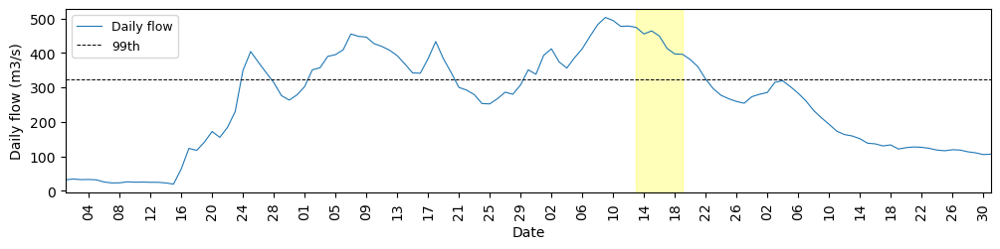

In [5]:
import matplotlib.dates as mdates
import matplotlib.units as munits
fig, ax = plt.subplots(figsize=(12., 2.4))
ax.plot(sel_river_data.index, sel_river_data['Daily flow'], label='Daily flow', linewidth=0.8)

ax.set_ylabel('Daily flow (m3/s)')
ax.set_xlabel('Date')
ax.set_xlim(sel_river_data.index[0], sel_river_data.index[-1])

locator = mdates.DayLocator(interval=4)
formatter = mdates.DateFormatter('%d')
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%M'))

ax.axvspan('2014-02-13', '2014-02-19', color='yellow', alpha=0.27)
ax.axhline(y=324, linewidth=0.7, color='black', linestyle='--', label='99th')
ax.legend(fontsize=9, loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()


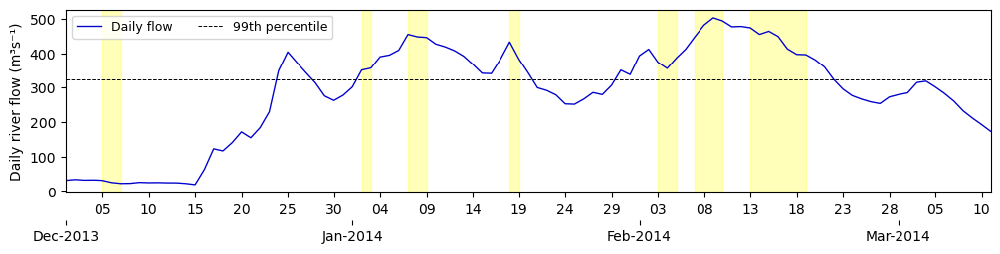

In [12]:

fig, ax = plt.subplots(figsize=(12, 2.4))
ax.plot(sel_river_data.index, sel_river_data['Daily flow'], label='Daily flow', color='mediumblue', linewidth=0.98)

ax.set_ylabel('Daily river flow (m³s⁻¹)')
ax.set_xlim(sel_river_data.index[0], sel_river_data.index[-21])

# Format the primary x-axis (Days)
locator = mdates.DayLocator(interval=5)
formatter = mdates.DateFormatter('%d')
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Secondary x-axis for months
secax = ax.secondary_xaxis(-0.001)
secax.xaxis.set_major_locator(mdates.MonthLocator())
secax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Additional formatting
secax.spines['bottom'].set_position(('outward', 20))
secax.spines['bottom'].set_visible(False)
#secax.set_xlabel('Date')

#ax.axvspan('2000-12-11', '2000-12-17', color='yellow', alpha=0.27)
ax.axvspan('2013-12-05', '2013-12-07', color='yellow', alpha=0.27)
ax.axvspan('2014-01-02', '2014-01-03', color='yellow', alpha=0.27)
ax.axvspan('2014-01-07', '2014-01-09', color='yellow', alpha=0.27)
ax.axvspan('2014-01-18', '2014-01-19', color='yellow', alpha=0.27)
ax.axvspan('2014-02-03', '2014-02-05', color='yellow', alpha=0.27)
ax.axvspan('2014-02-07', '2014-02-10', color='yellow', alpha=0.27)
ax.axvspan('2014-02-13', '2014-02-19', color='yellow', alpha=0.27)
ax.axhline(y=324, linewidth=0.7, color='black', linestyle='--', label='99th percentile')
ax.legend(fontsize=9, loc='upper left', ncol=2)
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

plt.show()


## Tidal data Sheerness

In [13]:
def clean_measurements(df, columns):
    for column in columns:
        # Ensure the column is treated as a string for the purpose of extraction
        df[column] = df[column].astype(str)
        
        # Create new columns for flags
        df[column + '_Flag'] = df[column].str.extract(r'([MNT])', expand=False)
        
        # Replace any variation of '-99.N' with '0' using regex
        df[column] = df[column].str.replace(r'-99\.0*0*N', '0', regex=True)
        
        # Handle general flagged values and convert to float
        def clean_value(value):
            # Remove flag characters and convert to float
            cleaned_value = value.replace('M', '').replace('N', '').replace('T', '').strip()
            return pd.to_numeric(cleaned_value, errors='coerce')
        
        # Apply the cleaning function to each entry
        df[column + '_Clean'] = df[column].apply(clean_value)

In [3]:
file_path = 'northsea/tide/1981SHE.txt'
def load_data(file_path):
    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        skiprows=11,  # Adjust this based on the file's structure
        names=['Raw_Number', 'Date', 'Time', 'Water surface elevation', 'Residual'],
        parse_dates={'Timestamp': ['Date', 'Time']},
        index_col=False
    )
    # Extract the numeric part of 'Raw_Number' for inspection but do not set it as index
    df['Number'] = df['Raw_Number'].str.extract(r'(\d+)').astype(int)
    return df

# Load the dataset
tidedata = load_data(file_path)

# Print the shape to verify the number of rows
print("Data shape:", tidedata.shape)

# Print a sample of the initial data to check the values around problematic indices
print("Initial data (sample):")
print(tidedata.head(20))

Data shape: (8760, 5)
Initial data (sample):
             Timestamp Raw_Number Water surface elevation Residual  Number
0  1981-01-01 00:00:00         1)                  2.8000   0.5071       1
1  1981-01-01 01:00:00         2)                  2.4130   0.5361       2
2  1981-01-01 02:00:00         3)                  2.2160   0.4611       3
3  1981-01-01 03:00:00         4)                  2.4590   0.5511       4
4  1981-01-01 04:00:00         5)                  3.0800   0.7400       5
5  1981-01-01 05:00:00         6)                  3.7910   0.8388       6
6  1981-01-01 06:00:00         7)                  4.3620   0.7608       7
7  1981-01-01 07:00:00         8)                  4.7870   0.5784       8
8  1981-01-01 08:00:00         9)                  5.1870   0.5917       9
9  1981-01-01 09:00:00        10)                  5.3320   0.7829      10
10 1981-01-01 10:00:00        11)                  4.9420   0.8862      11
11 1981-01-01 11:00:00        12)                  4.20

/tmp/ipykernel_1011/1604204534.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_1011/1604204534.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [233]:
def inspect_and_clean_measurements(df, columns, row_positions):
    for column in columns:
        # Convert the column to string type for processing and strip whitespace
        df[column] = df[column].astype(str).str.strip()

        # Replace multiple spaces with a single space
        df[column] = df[column].str.replace(r'\s+', ' ', regex=True)

        # Debug: Print initial values with hidden characters revealed
        print(f"Initial values in {column} (revealed hidden characters, specific rows):")
        print(df[column].iloc[row_positions].apply(repr))

        # Replace variations of '-99.0N' with '0'
        df[column] = df[column].replace(to_replace=r'-99\.0*0*N', value='0', regex=True)

        # Debug: Print after replacement
        print(f"After replacing '-99.0*N' with '0' in {column} (revealed hidden characters, specific rows):")
        print(df[column].iloc[row_positions].apply(repr))

        # Remove remaining flag characters (M, N, T)
        df[column] = df[column].replace(to_replace=r'[MNT]', value='', regex=True)

        # Debug: Print after removing flags
        print(f"After removing flags in {column} (revealed hidden characters, specific rows):")
        print(df[column].iloc[row_positions].apply(repr))

        # Convert cleaned values to numeric, coercing errors to NaN
        df[column + '_Clean'] = pd.to_numeric(df[column], errors='coerce')

        # Replace NaNs resulted from conversion to numeric for '-99.0*N' to 0
        df[column + '_Clean'].fillna(0, inplace=True)

        # Debug: Print final cleaned values
        print(f"Final cleaned values in {column}_Clean (specific rows):")
        print(df[column + '_Clean'].iloc[row_positions])

        # Summary of changes for debugging
        print(f"Summary for {column}:")
        print(f"Count of replacements to '0': {df[df[column] == '0'].shape[0]}")
        print(f"Count of NaNs after conversion: {df[column + '_Clean'].isna().sum()}")

# Positions of problematic rows to inspect
problematic_positions = [1494, 1495, 1496, 1497, 2636]

# Apply the cleaning function to the dataset
inspect_and_clean_measurements(tidedata, ['Water surface elevation', 'Residual'], problematic_positions)

# Print cleaned data around problematic rows by position
print("Cleaned data around problematic rows:")
print(tidedata.iloc[problematic_positions])


Initial values in Water surface elevation (revealed hidden characters, specific rows):
1494       '1.2210'
1495    '-99.0000N'
1496    '-99.0000N'
1497    '-99.0000N'
2636    '-99.0000N'
Name: Water surface elevation, dtype: object
After replacing '-99.0*N' with '0' in Water surface elevation (revealed hidden characters, specific rows):
1494    '1.2210'
1495         '0'
1496         '0'
1497         '0'
2636         '0'
Name: Water surface elevation, dtype: object
After removing flags in Water surface elevation (revealed hidden characters, specific rows):
1494    '1.2210'
1495         '0'
1496         '0'
1497         '0'
2636         '0'
Name: Water surface elevation, dtype: object
Final cleaned values in Water surface elevation_Clean (specific rows):
1494    1.221
1495    0.000
1496    0.000
1497    0.000
2636    0.000
Name: Water surface elevation_Clean, dtype: float64
Summary for Water surface elevation:
Count of replacements to '0': 2030
Count of NaNs after conversion: 0
Initial v

/tmp/ipykernel_606/2618044959.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column + '_Clean'].fillna(0, inplace=True)
/tmp/ipykernel_606/2618044959.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [14]:
tidepath = 'northsea/tide/'
all_tide_data = pd.DataFrame()

for year in range(1980, 2022):
    filetide = f'{tidepath}{year}SHE.txt'
    
    tidedata = pd.read_csv(
        filetide,
        delim_whitespace=True,
        skiprows=11,  # Adjust skiprows based on the actual structure of your file
        names=['Number', 'Date', 'Time', 'Water elevation', 'Residual'],
        parse_dates={'Timestamp': ['Date', 'Time']},
        index_col='Number'
    )
    
    tidedata.dropna(how='all', inplace=True)

    # Clean the measurements using the updated function
    clean_measurements(tidedata, ['Water elevation', 'Residual'])
    
    tidedata['Timestamp'] = pd.to_datetime(tidedata['Timestamp'], errors='coerce')
    tidedata.set_index('Timestamp', inplace=True)
    
    # Append cleaned data to the master DataFrame
    all_tide_data = pd.concat([all_tide_data, tidedata])

/tmp/ipykernel_1488/1818056862.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  tidedata = pd.read_csv(
/tmp/ipykernel_1488/1818056862.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tidedata = pd.read_csv(
/tmp/ipykernel_1488/1818056862.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  tidedata = pd.read_csv(
/tmp/ipykernel_1488/1818056862.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tidedata = pd.read_csv(
/tmp/ipykernel_1488/1818056862.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine t

In [4]:
all_tide_data

,Water elevation,Residual,Water elevation_Flag,Water elevation_Clean,Residual_Flag,Residual_Clean
Timestamp,,,,,,
1980-01-01 00:00:00,0,0,N,0.000,N,0.000
1980-01-01 01:00:00,0,0,N,0.000,N,0.000
1980-01-01 02:00:00,0,0,N,0.000,N,0.000
1980-01-01 03:00:00,0,0,N,0.000,N,0.000
1980-01-01 04:00:00,0,0,N,0.000,N,0.000
...,...,...,...,...,...,...
2021-12-31 22:45:00,5.695,0.290,NaN,5.695,NaN,0.290
2021-12-31 23:00:00,5.564,0.245,NaN,5.564,NaN,0.245
2021-12-31 23:15:00,5.374,0.195,NaN,5.374,NaN,0.195


In [12]:
from scipy.signal import find_peaks


start_date = '1993-01-01 00:00:00'
end_date = '2007-12-31 23:00:00'
selected_data = all_tide_data.loc[start_date:end_date]
water_surface_elevation = selected_data['Water elevation_Clean']

# Identify peaks and troughs
peaks, _ = find_peaks(water_surface_elevation)
troughs, _ = find_peaks(-water_surface_elevation)

# Calculate the amplitude for each peak using nearest trough
amplitudes = []
for peak in peaks:
    # Find the nearest preceding trough
    preceding_troughs = troughs[troughs < peak]
    preceding_trough = preceding_troughs[-1] if len(preceding_troughs) > 0 else None
    
    # Find the nearest succeeding trough
    succeeding_troughs = troughs[troughs > peak]
    succeeding_trough = succeeding_troughs[0] if len(succeeding_troughs) > 0 else None
    
    # Use the closest trough to calculate amplitude
    if preceding_trough is not None and succeeding_trough is not None:
        nearest_trough = preceding_trough if (peak - preceding_trough) < (succeeding_trough - peak) else succeeding_trough
    elif preceding_trough is not None:
        nearest_trough = preceding_trough
    elif succeeding_trough is not None:
        nearest_trough = succeeding_trough
    else:
        continue
    
    amplitude = water_surface_elevation[peak] - water_surface_elevation[nearest_trough]
    amplitudes.append(amplitude)

# Calculate the average amplitude
average_amplitude = np.mean(amplitudes)

average_amplitude

/tmp/ipykernel_1011/1632017581.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  amplitude = water_surface_elevation[peak] - water_surface_elevation[nearest_trough]


4.260404366770863

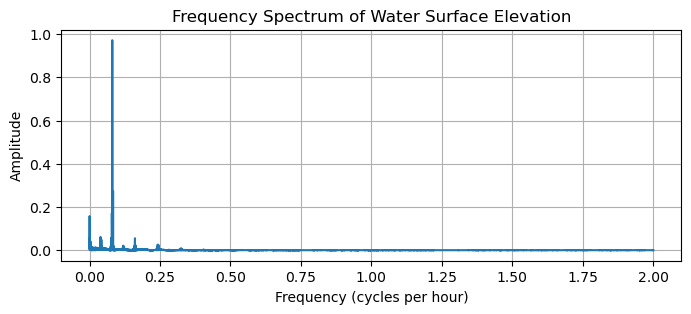

Significant periods (in hours): [1.46079167e+04 7.73360294e+03 1.26585066e+01 1.24205243e+01
 1.19999315e+01]


In [17]:
from scipy.signal import find_peaks, get_window

# Remove the mean to focus on variations
water_surface_elevation = water_surface_elevation - np.mean(water_surface_elevation)

# Apply a Hann window to reduce spectral leakage
window = get_window('hann', len(water_surface_elevation))
water_surface_elevation_windowed = water_surface_elevation * window

# Ensure the data is a properly aligned NumPy array
water_surface_elevation_windowed = np.ascontiguousarray(water_surface_elevation_windowed, dtype=np.float64)

# Number of sample points
N = len(water_surface_elevation_windowed)
# Sample spacing (hours)
T = 0.25  # Since the data is every 15 minutes, T is 0.25 hours

# Perform FFT
yf = fft(water_surface_elevation_windowed)
xf = fftfreq(N, T)[:N//2]  # Only take the positive frequencies

# Calculate the amplitude spectrum
amplitude_spectrum = 2.0/N * np.abs(yf[:N//2])

# Plot the FFT results
plt.figure(figsize=(8., 3.))
plt.plot(xf, amplitude_spectrum)
plt.title("Frequency Spectrum of Water Surface Elevation")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Convert frequencies to periods (in hours)
periods = 1 / xf[peaks]

# Print the significant periods (in hours)
print("Significant periods (in hours):", periods)

<Figure size 1300x300 with 0 Axes>

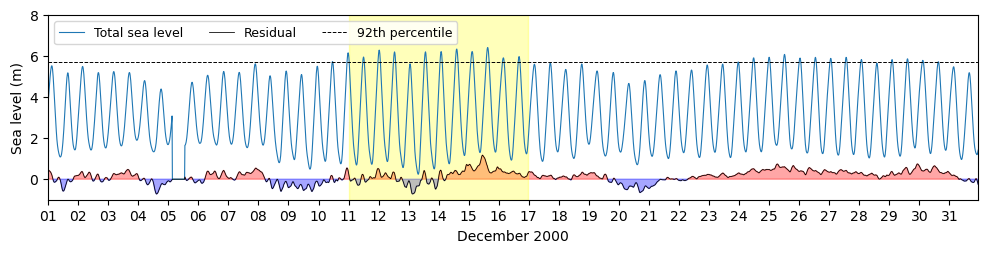

In [83]:
import matplotlib.dates as mdates

start_date = '2000-12-01 00:00:00'
end_date = '2000-12-31 23:00:00'
selected_data = all_tide_data.loc[start_date:end_date]

plt.figure(figsize=(13., 3.))

# Ensure the index is in datetime format
selected_data.index = pd.to_datetime(selected_data.index)

fig, ax = plt.subplots(figsize=(12., 2.4))

# Plot the water surface elevation
#selected_data['Water elevation_Clean'].plot(ax=ax, label='Water surface elevation', linewidth=1)
#selected_data['Residual_Clean'].plot(ax=ax, label='Residual', linewidth=1, color='black')

# Plot the water surface elevation
ax.plot(selected_data.index, selected_data['Water elevation_Clean'], label='Total sea level', linewidth=0.8)
ax.plot(selected_data.index, selected_data['Residual_Clean'], label='Residual', linewidth=0.57, color='black')

# Fill the area between the residual values and 0 with red color
ax.fill_between(selected_data.index, selected_data['Residual_Clean'], 0, where=(selected_data['Residual_Clean'] > 0), color='red', alpha=0.35, interpolate=True)
ax.fill_between(selected_data.index, selected_data['Residual_Clean'], 0, where=(selected_data['Residual_Clean'] < 0), color='blue', alpha=0.35, interpolate=True)

# Set labels, limits, and legend
ax.set_ylabel('Sea level (m)')
ax.set_ylim(-1, 8)
ax.set_xlabel('December 2000')
ax.set_xlim(selected_data.index[0], selected_data.index[-1])


locator = mdates.DayLocator(interval=1)  # Major ticks every 2 days
formatter = mdates.DateFormatter('%d')
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Set minor ticks for better readability
#ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

ax.axvspan('2000-12-11 00:00:00', '2000-12-16 23:00:00', color='yellow', alpha=0.27)
ax.axhline(y=5.691, linewidth=0.7, color='black', linestyle='--', label='92th percentile')
ax.legend(fontsize=9, loc='upper left', ncol=3)
# Rotate and align the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
#plt.title('Sea surface level observation at Sheerness', loc='left')
plt.show()


In [33]:
#all_tide_data['Water elevation_Clean'].quantile(0.92)
selected_data['Residual_Clean'].max()

1.171

In [34]:
#selected_data[selected_data['Water elevation_Clean']==6.41]
selected_data[selected_data['Residual_Clean']==1.171]

,Water elevation,Residual,Water elevation_Flag,Water elevation_Clean,Residual_Flag,Residual_Clean
Timestamp,,,,,,
2000-12-15 11:00:00,2.724,1.171,NaN,2.724,NaN,1.171


<Figure size 1300x300 with 0 Axes>

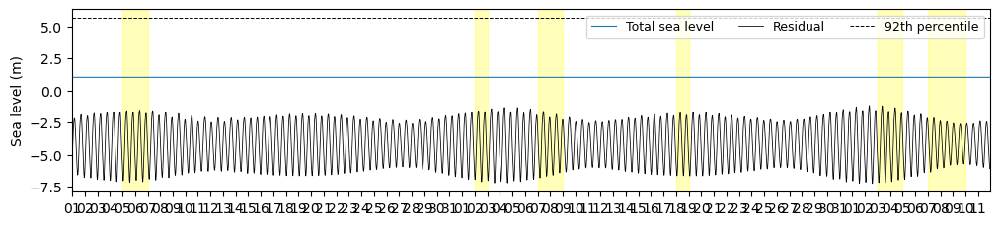

In [26]:
import matplotlib.dates as mdates

start_date = '2013-12-01 00:00:00'
end_date = '2014-02-11 23:00:00'
selected_data = all_tide_data.loc[start_date:end_date]

plt.figure(figsize=(13., 3.))

# Ensure the index is in datetime format
selected_data.index = pd.to_datetime(selected_data.index)

fig, ax = plt.subplots(figsize=(12., 2.4))

# Plot the water surface elevation
#selected_data['Water elevation_Clean'].plot(ax=ax, label='Water surface elevation', linewidth=1)
#selected_data['Residual_Clean'].plot(ax=ax, label='Residual', linewidth=1, color='black')

# Plot the water surface elevation
ax.plot(selected_data.index, (selected_data['Water elevation_Clean']*-1), label='Total sea level', linewidth=0.8)
ax.plot(selected_data.index, selected_data['Residual_Clean'], label='Residual', linewidth=0.57, color='black')

# Fill the area between the residual values and 0 with red color
#ax.fill_between(selected_data.index, selected_data['Residual_Clean']*-1, 0, where=(selected_data['Residual_Clean'] > 0), color='red', alpha=0.35, interpolate=True)
#ax.fill_between(selected_data.index, selected_data['Residual_Clean']*-1, 0, where=(selected_data['Residual_Clean'] < 0), color='blue', alpha=0.35, interpolate=True)

# Set labels, limits, and legend
ax.set_ylabel('Sea level (m)')
#ax.set_ylim(-1, 8)
#ax.set_xlabel('December 2000')
ax.set_xlim(selected_data.index[0], selected_data.index[-1])


locator = mdates.DayLocator(interval=1)  # Major ticks every 2 days
formatter = mdates.DateFormatter('%d')
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Set minor ticks for better readability
#ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

ax.axvspan('2013-12-05', '2013-12-07', color='yellow', alpha=0.27)
ax.axvspan('2014-01-02', '2014-01-03', color='yellow', alpha=0.27)
ax.axvspan('2014-01-07', '2014-01-09', color='yellow', alpha=0.27)
ax.axvspan('2014-01-18', '2014-01-19', color='yellow', alpha=0.27)
ax.axvspan('2014-02-03', '2014-02-05', color='yellow', alpha=0.27)
ax.axvspan('2014-02-07', '2014-02-10', color='yellow', alpha=0.27)
ax.axvspan('2014-02-13', '2014-02-19', color='yellow', alpha=0.27)
ax.axhline(y=5.691, linewidth=0.7, color='black', linestyle='--', label='92th percentile')
ax.legend(fontsize=9, loc='upper right', ncol=3)
# Rotate and align the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
#plt.title('Sea surface level observation at Sheerness', loc='left')
plt.show()


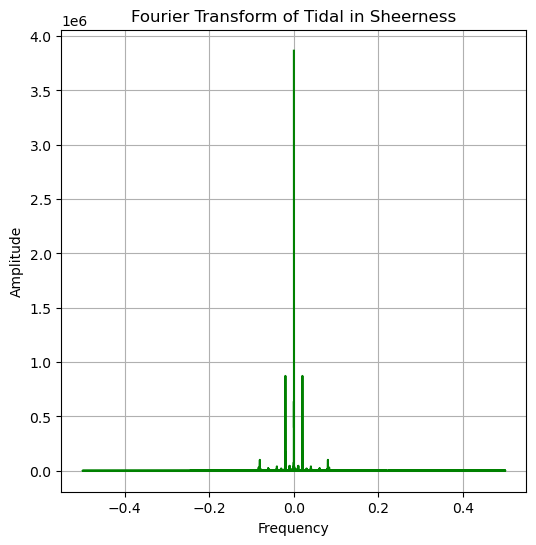

In [5]:
from scipy.fft import fft
# Perform Fourier Transform to identify dominant frequencies
# Assuming your data is evenly sampled
t = np.arange(0, len(all_tide_data), 1)
y = all_tide_data['Water elevation_Clean'].values
fft_result = fft(y)
frequencies = np.fft.fftfreq(len(y), 1)  # Assuming 1 unit of time per data point

# Plot the Fourier Transform results
plt.figure(figsize=(6., 6.))
plt.plot(frequencies, np.abs(fft_result), color='green')
plt.title('Fourier Transform of Tidal in Sheerness')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [39]:
start_date = '1993-01-01 00:00:00'
end_date = '2022-12-31 23:00:00'
best_data = all_tide_data.loc[start_date:end_date]

/opt/jaspy/lib/python3.11/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


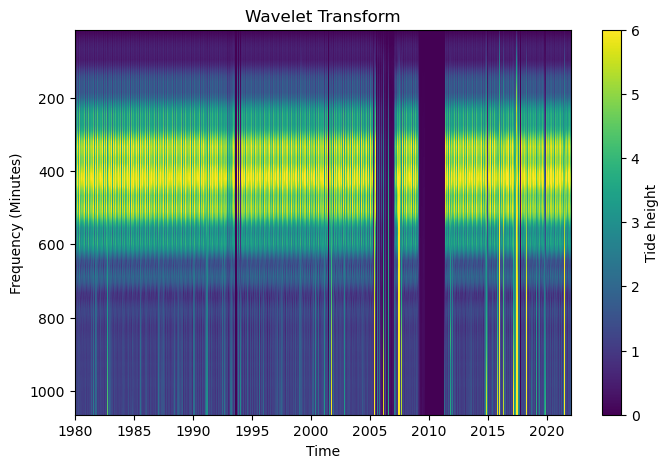

In [41]:
import pywt
# Perform Wavelet Transform
data = best_data['Water elevation_Clean'].values
wavelet = 'cmor'  # Choose a wavelet function, e.g., 'cmor' for complex Morlet
scales = np.arange(1, 72)  # Define a range of scales to analyze
coefficients, frequencies = pywt.cwt(data, scales, wavelet)

# Plot using imshow
plt.figure(figsize=(8., 5.))
plt.imshow(np.abs(coefficients), extent=[all_tide_data.index[0], all_tide_data.index[-1], scales[-1]*15, scales[0]*15],
           aspect='auto', cmap='jet', interpolation='bilinear', vmin=0, vmax=8)
plt.colorbar(label='Tide height')
plt.title('Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Frequency (Minutes)')
plt.show()

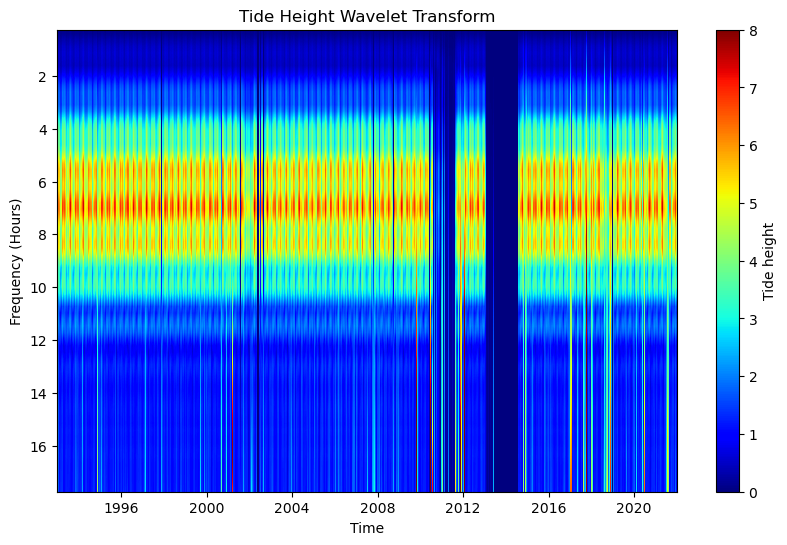

In [44]:
data = best_data['Water elevation_Clean'].values
wavelet = 'cmor'  # Choose a wavelet function, e.g., 'cmor' for complex Morlet
scales = np.arange(1, 72)  # Define a range of scales to analyze

# Perform Wavelet Transform
coefficients, frequencies = pywt.cwt(data, scales, wavelet, sampling_period=15*60)  # sampling period is 15 minutes (900 seconds)

# Convert scales to hours (since the sampling interval is 15 minutes, which is 0.25 hours)
scale_hours = scales * 0.25

# Use the actual timestamps from your dataset for the x-axis
time = best_data.index  # Assuming best_data.index contains the timestamps

# Plot using imshow
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scale_hours[-1], scale_hours[0]],
           aspect='auto', cmap='jet', interpolation='bilinear', vmin=0, vmax=8)
plt.colorbar(label='Tide height')
plt.title('Tide Height Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Frequency (Hours)')
plt.show()


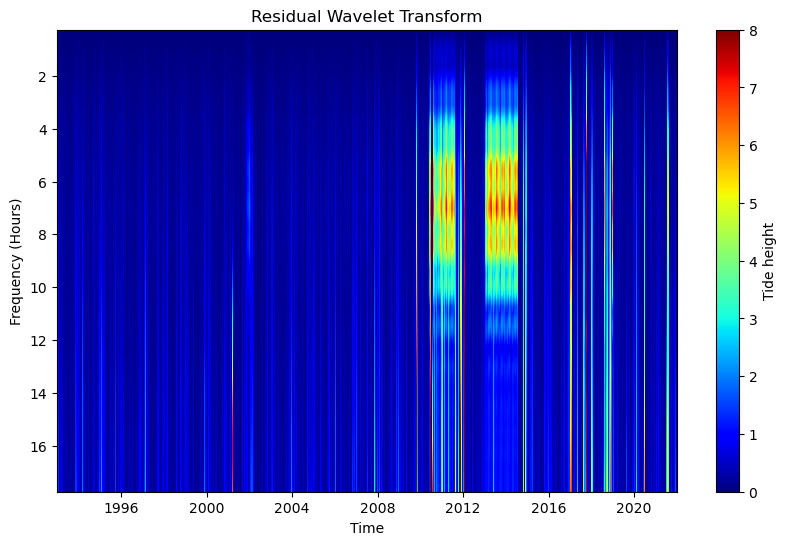

In [45]:
data = best_data['Residual_Clean'].values
wavelet = 'cmor'  # Choose a wavelet function, e.g., 'cmor' for complex Morlet
scales = np.arange(1, 72)  # Define a range of scales to analyze

# Perform Wavelet Transform
coefficients, frequencies = pywt.cwt(data, scales, wavelet, sampling_period=15*60)  # sampling period is 15 minutes (900 seconds)

# Convert scales to hours (since the sampling interval is 15 minutes, which is 0.25 hours)
scale_hours = scales * 0.25

# Use the actual timestamps from your dataset for the x-axis
time = best_data.index  # Assuming best_data.index contains the timestamps

# Plot using imshow
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scale_hours[-1], scale_hours[0]],
           aspect='auto', cmap='jet', interpolation='bilinear', vmin=0, vmax=8)
plt.colorbar(label='Tide height')
plt.title('Residual Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Frequency (Hours)')
plt.show()


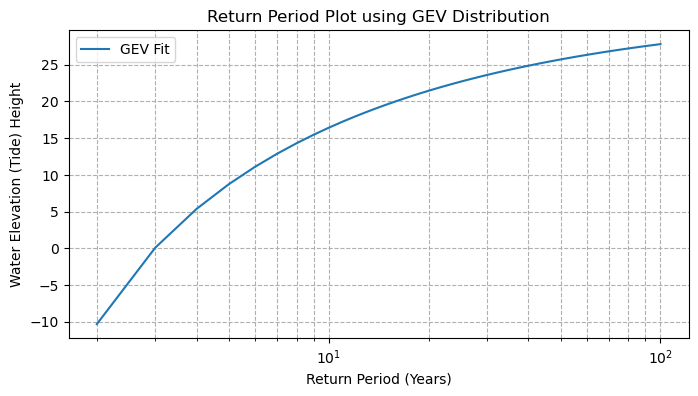

In [48]:
from scipy.stats import genextreme

# Assuming best_data is already defined and contains a 'Water elevation_Clean' column
data = best_data['Water elevation_Clean'].values

# Fit the GEV distribution to the data
params = genextreme.fit(data)
c, loc, scale = params

# Define the return periods (in years)
return_periods = np.linspace(1, 100, 100)  # For example, from 1 to 1000 years

# Calculate the corresponding quantiles (inverse CDF of GEV)
elevations = genextreme.ppf(1 - 1 / return_periods, c, loc, scale)

# Create the plot
plt.figure(figsize=(8., 4.))
plt.plot(return_periods, elevations, label='GEV Fit')
plt.xlabel('Return Period (Years)')
plt.ylabel('Water Elevation (Tide) Height')
plt.xscale('log')
plt.title('Return Period Plot using GEV Distribution')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


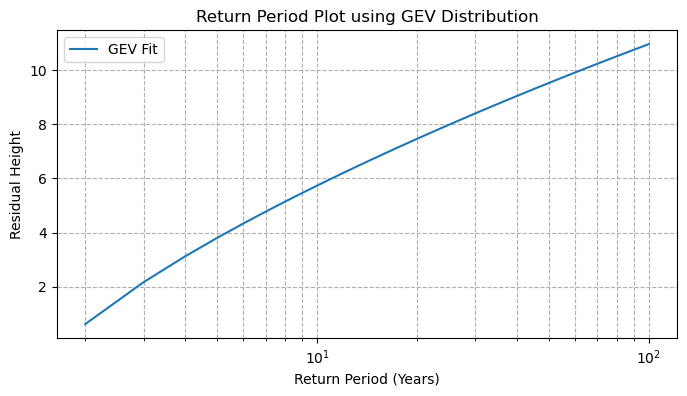

In [49]:
data = best_data['Residual_Clean'].values

# Fit the GEV distribution to the data
params = genextreme.fit(data)
c, loc, scale = params

# Define the return periods (in years)
return_periods = np.linspace(1, 100, 100)  # For example, from 1 to 1000 years

# Calculate the corresponding quantiles (inverse CDF of GEV)
elevations = genextreme.ppf(1 - 1 / return_periods, c, loc, scale)

# Create the plot
plt.figure(figsize=(8., 4.))
plt.plot(return_periods, elevations, label='GEV Fit')
plt.xlabel('Return Period (Years)')
plt.ylabel('Residual Height')
plt.xscale('log')
plt.title('Return Period Plot using GEV Distribution')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


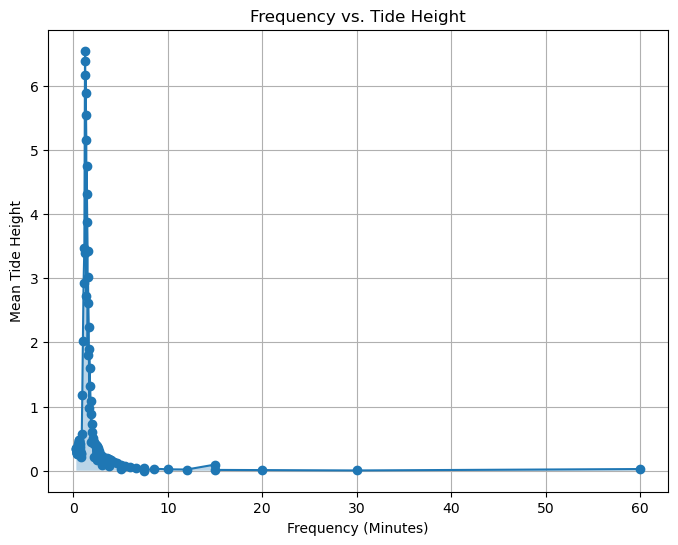

In [45]:
date_change = '1993-01-01 00:00:00'
# Split data into segments based on sampling interval
data_15min = all_tide_data[all_tide_data.index <= date_change]['Water elevation_Clean']
data_60min = all_tide_data[all_tide_data.index > date_change]['Water elevation_Clean']

# Perform Wavelet Transform for 15-minute data
wavelet = 'cmor1.5-1.0'
scales_15min = np.arange(1, 50)
coefficients_15min, frequencies_15min = pywt.cwt(data_15min.values, scales_15min, wavelet)

# Perform Wavelet Transform for 60-minute data
scales_60min = np.arange(1, 50)
coefficients_60min, frequencies_60min = pywt.cwt(data_60min.values, scales_60min, wavelet)

# Convert scales to frequencies in minutes
sampling_interval_15min = 15
sampling_interval_60min = 60
sampling_frequency_15min = 1 / sampling_interval_15min
sampling_frequency_60min = 1 / sampling_interval_60min
central_frequency = pywt.central_frequency(wavelet)
frequencies_in_minutes_15min = central_frequency / (scales_15min * sampling_frequency_15min)
frequencies_in_minutes_60min = central_frequency / (scales_60min * sampling_frequency_60min)

# Calculate the mean magnitude of coefficients for each frequency
mean_magnitudes_15min = np.mean(np.abs(coefficients_15min), axis=1)
mean_magnitudes_60min = np.mean(np.abs(coefficients_60min), axis=1)

# Combine results
frequencies_combined = np.concatenate((frequencies_in_minutes_60min, frequencies_in_minutes_15min))
mean_magnitudes_combined = np.concatenate((mean_magnitudes_60min, mean_magnitudes_15min))

# Sort combined results by frequency
sorted_indices = np.argsort(frequencies_combined)
frequencies_sorted = frequencies_combined[sorted_indices]
mean_magnitudes_sorted = mean_magnitudes_combined[sorted_indices]

# Plotting the mean magnitudes versus frequency in minutes
plt.figure(figsize=(8., 6.))
plt.plot(frequencies_sorted, mean_magnitudes_sorted, marker='o', linestyle='-')
plt.fill_between(frequencies_sorted, mean_magnitudes_sorted, alpha=0.3)
plt.title('Frequency vs. Tide Height')
plt.xlabel('Frequency (Minutes)')
plt.ylabel('Mean Tide Height')
plt.grid(True)
plt.show()

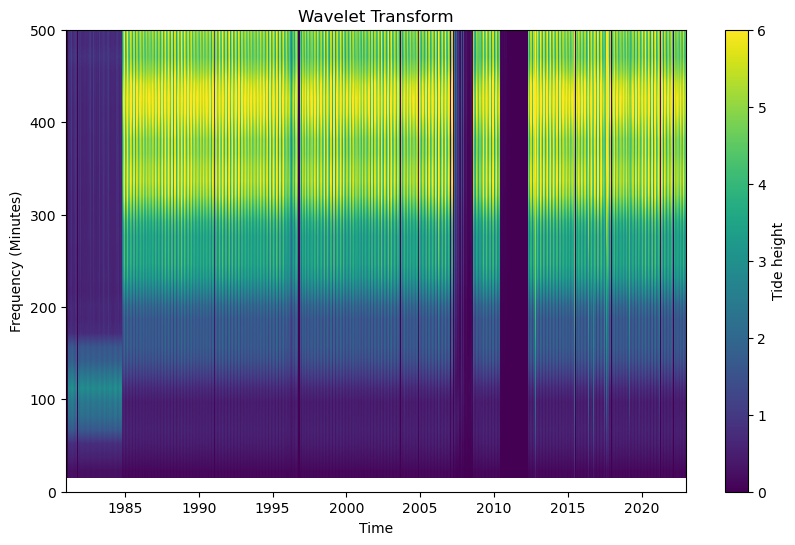

In [34]:
data = all_tide_data['Water elevation_Clean'].values
wavelet = 'cmor'  # Choose a wavelet function, e.g., 'cmor' for complex Morlet
scales = np.arange(1, 200)  # Define a range of scales to analyze
coefficients, frequencies = pywt.cwt(data, scales, wavelet)

# Plot using imshow
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), extent=[all_tide_data.index[0], all_tide_data.index[-1], scales[-1]*15, scales[0]*15],
           aspect='auto', cmap='viridis', interpolation='bilinear', vmin=0, vmax=6)
plt.colorbar(label='Tide height')
plt.title('Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Frequency (Minutes)')
plt.ylim([0, 500])  # Focus on a specific frequency range if needed
plt.show()


/opt/jaspy/lib/python3.11/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


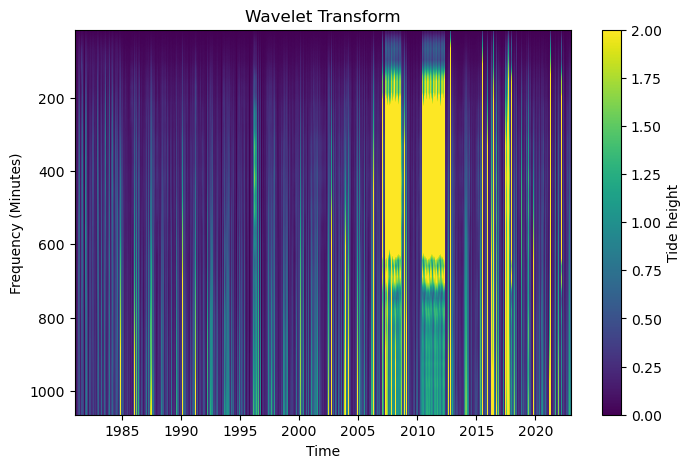

In [33]:
data = all_tide_data['Residual_Clean'].values
wavelet = 'cmor'  # Choose a wavelet function, e.g., 'cmor' for complex Morlet
scales = np.arange(1, 72)  # Define a range of scales to analyze
coefficients, frequencies = pywt.cwt(data, scales, wavelet)

# Plot using imshow
plt.figure(figsize=(8., 5.))
plt.imshow(np.abs(coefficients), extent=[all_tide_data.index[0], all_tide_data.index[-1], scales[-1]*15, scales[0]*15],
           aspect='auto', cmap='viridis', interpolation='bilinear', vmin=0, vmax=2)
plt.colorbar(label='Tide height')
plt.title('Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Frequency (Minutes)')
plt.show()


/tmp/ipykernel_522/3638989769.py:7: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  coefficients = cwt(data, wavelet, scales)


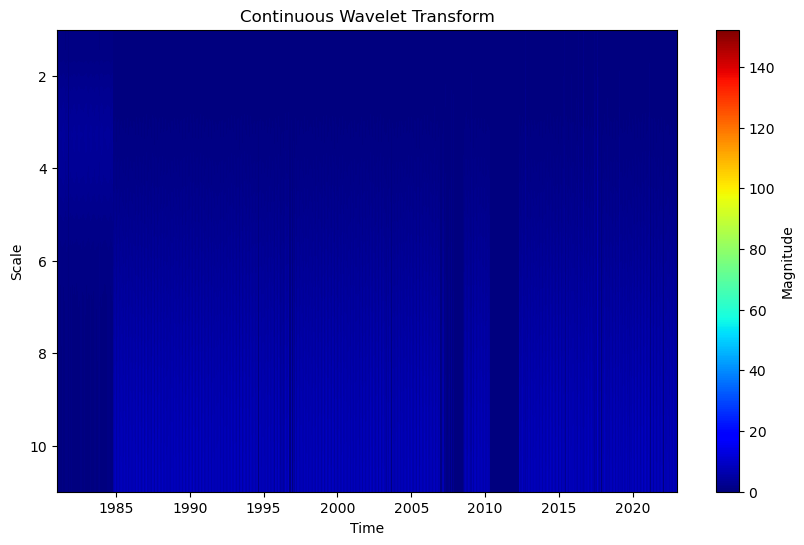

In [13]:
from scipy.signal import cwt, ricker

# Perform Continuous Wavelet Transform (CWT)
data = all_tide_data['Water elevation_Clean'].values
scales = np.arange(1, 12)  # Define a range of scales to analyze
wavelet = ricker  # Choose a wavelet function, e.g., Ricker wavelet
coefficients = cwt(data, wavelet, scales)

# Plot CWT results
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), extent=[all_tide_data.index[0], all_tide_data.index[-1], scales[-1], scales[0]],
           aspect='auto', cmap='jet', interpolation='bilinear')
plt.colorbar(label='Magnitude')
plt.title('Continuous Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()


In [27]:
selected_data['Water elevation_Clean'].plot()

In [18]:
selected_data

,Water elevation,Residual,Water elevation_Flag,Water elevation_Clean,Residual_Flag,Residual_Clean
Timestamp,,,,,,
2013-10-21 00:00:00,-1.027M,-5.901M,M,-1.027,M,-5.901
2013-10-21 00:15:00,-1.027M,-6.167M,M,-1.027,M,-6.167
2013-10-21 00:30:00,-1.027M,-6.416M,M,-1.027,M,-6.416
2013-10-21 00:45:00,-1.027M,-6.634M,M,-1.027,M,-6.634
2013-10-21 01:00:00,-1.027M,-6.806M,M,-1.027,M,-6.806
...,...,...,...,...,...,...
2014-10-26 22:00:00,8.386M,6.276M,M,8.386,M,6.276
2014-10-26 22:15:00,10.267M,7.846M,M,10.267,M,7.846
2014-10-26 22:30:00,-1.098M,-3.818M,M,-1.098,M,-3.818


<Axes: xlabel='Timestamp'>

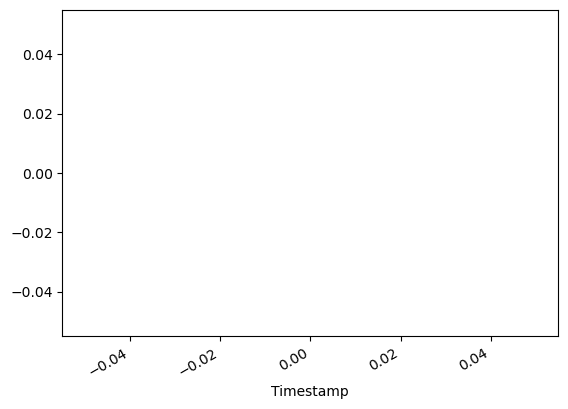

In [5]:
all_tide_data.sort_index(inplace=True)
start_date = '2001-10-01 00:00:00'
end_date = '2002-05-30 23:00:00'
selected_data = all_tide_data.loc[start_date:end_date]
selected_data['Water elevation_Clean'].plot()

In [132]:
# Check if index is monotonic
# Ensure the 'Timestamp' index is in datetime format
all_tide_data.index = pd.to_datetime(all_tide_data.index)

# Sort the DataFrame by the index to ensure monotonicity
all_tide_data.sort_index(inplace=True)
print(all_tide_data.index.is_monotonic_increasing)

# Check min and max dates in the index
print(all_tide_data.index.min())
print(all_tide_data.index.max())

# Check for specific dates
print('1984-01-01 00:00:00' in all_tide_data.index)
print('1984-12-31 23:00:00' in all_tide_data.index)


True
1980-01-01 00:00:00
2022-12-31 23:45:00
True
True


## Function to read Storm Track

In [3]:
def read_tracks(filename=None, var_names=None):
    regex_clean = re.compile(r'&')
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)

    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]

        track_lines = [regex_clean.sub('', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        columns = ['ID', 'start_time', 'median_time', 'name']
        split_line = lines[i_start[ii]].split()
        
        id_id = split_line[1] if len(split_line) > 1 else 'unknown'
        start_time = split_line[3] if len(split_line) > 3 else 'unknown'
        median_time = split_line[5] if len(split_line) > 5 else 'unknown'
        name_storm = split_line[9] if len(split_line) > 9 else 'unknown'
        
        df = pd.DataFrame(data, columns=var_names[:data.shape[1]])
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)
    result['ID'] = result['ID'].astype('category')

    return result

In [2]:
def read_tracks(filename=None, var_names=None):
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)
    #print(i_start, n_tracks)
    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]
        track_lines = [re.sub(r'&', '', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        df = pd.DataFrame(data)
        id_id = '_'.join(lines[i_start[ii]].split()[1:2])
        start_time = '_'.join(lines[i_start[ii]].split()[3:4])
        median_time = '_'.join(lines[i_start[ii]].split()[5:6])
        name_storm = '_'.join(lines[i_start[ii]].split()[9:10])
        
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)

    result['ID'] = result['ID'].astype('category')

    if var_names:
        for idx, name in enumerate(var_names, start=0):
            result.rename(columns={idx: name}, inplace=True)

    return result

def add_wrap_id(df):
    df.columns = [str(col) for col in df.columns]
    lon_cols = [col for col in df.columns if col.startswith('lon_')]

    for lon_col in lon_cols:
        suffix = lon_col.split('_')[-1]
        lat_col = f'lat_{suffix}'

        def calculate_wrap_id(lon):
            diffs = np.diff(np.concatenate(([lon.iloc[0]], lon))) 
            wraps = diffs > 180 
            return np.cumsum(wraps) + 1  

        if 'ID' in df.columns:
            df[f'wrap_{suffix}'] = df.groupby('ID')[lon_col].transform(calculate_wrap_id)
            df[f'ID2_{suffix}'] = df['ID'].astype(str) + '.' + df[f'wrap_{suffix}'].astype(str)
        else:
            df[f'wrap_{suffix}'] = calculate_wrap_id(df[lon_col])
            df[f'ID2_{suffix}'] = df.index.astype(str) + '.' + df[f'wrap_{suffix}'].astype(str)

        df.drop(f'wrap_{suffix}', axis=1, inplace=True)
    
    df['TRACK_ID'] = df['ID'].str.split('_').str[-1]

    return df

In [5]:
def plot_track(data, var, fig_title):
    '''
    Plot storm tracks on a map.

    Parameters:
    data : DataFrame containing the storm track data.
    var : str, one of 'vor', 'wind', 'mslp' indicating the variable to be plotted.
    fig_title : str, the title of the figure.
    '''

    var_name = {'vor': (1, 9, 'vorticity (×10⁻⁵ s⁻¹)'),
                'wind': (10, 50, '925-hPa wind speed max (m s⁻¹)'),
                'mslp': (960, 1010, 'mean sea level pressure (hPa)')}

    datacrs = ccrs.PlateCarree()
    #mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  
    data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180

    fig, ax = plt.subplots(figsize=(10., 10.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis_r
    norm = plt.Normalize(var_name[var][0], var_name[var][1])

    for name, group in data.groupby('ID'):
        points = group[[f'lon_{var}', f'lat_{var}']].values
        color_values = norm(group[f'var_{var}'])
        ax.scatter(group[f'lon_{var}'], group[f'lat_{var}'], color=cmap(color_values),
                   s=1, transform=datacrs, alpha=1)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = (group[f'var_{var}'].iloc[i] + group[f'var_{var}'].iloc[i + 1]) / 2
            ax.plot(line[:, 0], line[:, 1], color=cmap(norm(mid_value)),
                    linewidth=0.5, transform=datacrs, alpha=1)

    #ax.add_patch(mpatches.Rectangle(xy=[-15, 35], width=45, height=35, zorder=18,
    #                            facecolor='none', edgecolor='red', transform=datacrs))
    
    #ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=19,
    #                            facecolor='none', edgecolor='black', transform=datacrs))
    
    ax.set_title(fig_title)
    labelin = var_name[var][2]
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()


In [28]:
def plot_track_wind_season(data):
    '''
    Plot storm tracks on a map.

    Parameters:
    data : DataFrame containing the storm track data.
    var : str, one of 'vor', 'wind', 'mslp' indicating the variable to be plotted.
    fig_title : str, the title of the figure.
    '''    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data['lon_vor'] = ((data['lon_vor'] + 180) % 360) - 180
    season = data['season'].iloc[0]
    n_storm = data['ID'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis
    norm = Normalize(2, 20)

    # Processing each group
    for name, group in data.groupby('ID'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group['speed'] = pd.to_numeric(group['speed'], errors='coerce')
        group['speed'].fillna(group['speed'].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group['speed'].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors
        max_wind = group['var_wind'].max()
        
        #ax.scatter(group['lon_vor'], group['lat_vor'], color=colors, s=1, transform=datacrs)
        ax.plot(group['lon_vor'], group['lat_vor'], max_wind, '*', s=1, transform=datacrs)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['speed'].iloc[i] + group['speed'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.5, transform=datacrs)

    #ax.set_title(f'Extratropical Cyclone in North Sea {season} (n={n_storm})')
    ax.set_title(f'Extratropical Cyclone in North Sea within Thames Barrier Closure Date Window (n={n_storm})')
    labelin = 'track propagation speed (km/h)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()


In [7]:
def plot_track(data, var, fig_title):
    '''
    data: storm track dataframe
    var: 'vor', 'wind', 'mslp'
    '''

    var_name = {'vor': (0,9, 'vorticity (x10-5 s-1)'), 
                'wind': (10,50, '925-hPa windspeed max (ms-1)'), 
                'mslp': (960,1010, 'mean sea level pressure (hPa)')}
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = plt.Normalize(var_name[var][0], var_name[var][1])
    colors = cmap(norm(data[f'var_{var}']))
    
    for name, group in data.groupby('ID'):
        lon = group[f'lon_{var}'].values
        lat = group[f'lat_{var}'].values
        color = colors[group.index]
        
        ax.scatter(lon, lat, color=color, s=1, transform=datacrs)
        
        for i in range(len(lon) - 1):
            ax.plot([lon[i], lon[i+1]], [lat[i], lat[i+1]], 
                    color=cmap(norm((group[f'var_{var}'].iloc[i] + group[f'var_{var}'].iloc[i+1]) / 2)),
                    linewidth=0.5, transform=datacrs)
        
    ax.set_title(fig_title)
    labelin = f'{var_name[var][2]}'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()

In [27]:
def plot_density (data, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
    ax.set_extent([-95, 65, 25, 90], crs=ccrs.PlateCarree())
    #ax.set_extent([-180, 28, 25, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
    
    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape)
    
    sc = ax.scatter(lons, lats, c=kde(xy), s=10, cmap='viridis_r', edgecolor='none', transform=datacrs)
    cs = ax.contour(lon_grid, lat_grid, z, levels=6, colors='k', linewidths=0.5, transform=datacrs)
    plt.clabel(cs, inline=1, fontsize=5, fmt='%.4f')
    
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cbar.set_label('Density')
    ax.set_title(fig_title)
    #plt.savefig('storm_19792021_density.png', dpi=300)
    plt.show()

In [4]:
def to_datetime(df):
    df['date'] = df['date'].astype(str)
    df['start_time'] = df['start_time'].astype(str)
    #df['median_time'] = df['median_time'].astype(str)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d%H.%f')
    df['start_time'] = pd.to_datetime(df['start_time'], format='%Y%m%d%H')
    #df['median_time'] = pd.to_datetime(df['median_time'], format='%Y%m%d%H', errors='coerce')
    
    return df

def get_season(date):
    year = date.year
    if date.month in [10, 11, 12]:
        return f"{year}-{year+1}"
    elif date.month in [1, 2, 3]:
        return f"{year-1}-{year}"
    else:
        return None 

## ERA5_VOR850 

In [16]:
filename2 = 'northsea/merged_track.txt'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_all = read_tracks(filename2, var_names)
trx_all = to_datetime(trx_all)
trx_all['season'] = trx_all['start_time'].apply(get_season)
trx_all.head()

In [3]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
filenamex = fpath + 'ERA5_VOR850_1hr_oct-mar20202021_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
with open(filenamex, 'r') as file:
    for i in range(8):
        print(file.readline().strip())

In [7]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
for i in range(1970, 1983):
    fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
    filename = f'ERA5_VOR850_1hr_oct-mar{i}{i+1}_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
    trx_all = read_tracks(fpath+filename, var_names)
trx_2122 = to_datetime(trx_2122)
trx_2122['season'] = trx_2122['start_time'].apply(get_season)
trx_2122.head()

0
0 0
TRACK_NUM      3490 ADD_FLD    3   9 &111
TRACK_ID  1 START_TIME 2021100100
POINT_NUM  46
2021100100 316.288605 6.533656 2.588414e+00 & 3.128009e+02 & 5.472016e+00 & 1.011661e+03 & 3.116250e+02 & 9.133487e+00 & 1.131191e+01 & 3.130312e+02 & 1.138173e+01 & 9.158251e+00 &
2021100101 316.053741 6.525511 2.615831e+00 & 3.148244e+02 & 4.635773e+00 & 1.012083e+03 & 3.113438e+02 & 9.133487e+00 & 1.109850e+01 & 3.130312e+02 & 1.081967e+01 & 9.497718e+00 &
2021100102 315.755066 6.478238 2.567494e+00 & 3.172072e+02 & 5.706082e+00 & 1.012187e+03 & 3.135938e+02 & 9.133487e+00 & 1.186456e+01 & 3.121875e+02 & 1.110070e+01 & 9.899447e+00 &


,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
0,2021-10-01 00:00:00,316.288605,6.533656,2.588414,312.8009,5.472016,1011.661,311.6250,9.133487,11.31191,313.0312,11.38173,9.158251,1,2021-10-01,NaT,unknown,2021-2022
1,2021-10-01 01:00:00,316.053741,6.525511,2.615831,314.8244,4.635773,1012.083,311.3438,9.133487,11.09850,313.0312,10.81967,9.497718,1,2021-10-01,NaT,unknown,2021-2022
2,2021-10-01 02:00:00,315.755066,6.478238,2.567494,317.2072,5.706082,1012.187,313.5938,9.133487,11.86456,312.1875,11.10070,9.899447,1,2021-10-01,NaT,unknown,2021-2022
3,2021-10-01 03:00:00,315.368164,6.450430,2.584446,317.2607,6.334778,1011.610,313.8750,8.852456,12.11530,312.4688,10.81967,10.149240,1,2021-10-01,NaT,unknown,2021-2022
4,2021-10-01 04:00:00,315.130249,6.447303,2.569178,315.9538,6.474955,1010.869,313.0312,9.133487,12.45928,311.6250,11.10070,10.435960,1,2021-10-01,NaT,unknown,2021-2022


In [29]:
#Storms, identified for downscaling and footprinting, and are selected by applying a threshold value of 25m/s to land only 10m wind speeds attached to the tracks
# -15W, 25E, 35N, 70N
# -15W, 25E, 50N, 60N

europe_bound = trx_2122[(trx_2122['lon_vor'] >= -6) & (trx_2122['lon_vor'] <= 9) & 
                      (trx_2122['lat_vor'] >= 50) & (trx_2122['lat_vor'] <= 60)]

valid_ids = europe_bound['ID'].unique()
trx_2122_europe = trx_2122[trx_2122['ID'].isin(valid_ids)]
trx_2122_europe

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
2719,2021-10-01 14:00:00,328.691162,47.323318,3.016048,329.457000,46.75023,1014.494,330.1875,44.82434,23.07317,329.34380,45.94846,12.69816,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2720,2021-10-01 15:00:00,329.843506,47.154934,3.253570,330.296700,46.83046,1013.507,331.3125,45.10537,23.87256,329.90620,45.94846,12.84404,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2721,2021-10-01 16:00:00,330.884186,47.125778,3.567819,331.198100,46.80598,1012.237,331.8750,45.38640,24.21362,330.75000,45.94846,13.16867,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2722,2021-10-01 17:00:00,331.821289,47.093708,3.738206,331.978600,46.77438,1011.087,332.4375,45.38640,24.59600,331.59380,45.94846,13.58831,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2723,2021-10-01 18:00:00,332.816254,47.029953,3.878100,332.862100,46.70602,1010.601,333.2812,45.38640,25.23026,332.43750,45.94846,13.94014,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211329,2022-03-31 19:00:00,5.605659,51.174637,6.186520,NaN,NaN,1000.378,2.2500,51.85009,26.48362,2.25000,51.85009,17.38300,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211330,2022-03-31 20:00:00,5.573274,51.118286,6.300493,NaN,NaN,1000.609,2.2500,51.56907,27.68898,2.25000,51.56907,17.76185,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211331,2022-03-31 21:00:00,5.456001,51.060047,6.606428,NaN,NaN,1000.509,2.2500,51.56907,28.54635,2.53125,51.56907,17.98296,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211332,2022-03-31 22:00:00,5.178141,50.801155,6.820322,3.878088,50.97361,1001.114,2.2500,51.28803,29.81559,2.81250,51.56907,19.40669,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022


In [30]:
wind_threshold = trx_2122_europe[(trx_2122_europe['var_wind'] >= 25)]
valid_idss = wind_threshold['ID'].unique()
trx_2122_europe_strong = trx_2122_europe[trx_2122_europe['ID'].isin(valid_idss)]
trx_2122_europe_strong

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
2719,2021-10-01 14:00:00,328.691162,47.323318,3.016048,329.457000,46.75023,1014.494,330.1875,44.82434,23.07317,329.34380,45.94846,12.69816,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2720,2021-10-01 15:00:00,329.843506,47.154934,3.253570,330.296700,46.83046,1013.507,331.3125,45.10537,23.87256,329.90620,45.94846,12.84404,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2721,2021-10-01 16:00:00,330.884186,47.125778,3.567819,331.198100,46.80598,1012.237,331.8750,45.38640,24.21362,330.75000,45.94846,13.16867,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2722,2021-10-01 17:00:00,331.821289,47.093708,3.738206,331.978600,46.77438,1011.087,332.4375,45.38640,24.59600,331.59380,45.94846,13.58831,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2723,2021-10-01 18:00:00,332.816254,47.029953,3.878100,332.862100,46.70602,1010.601,333.2812,45.38640,25.23026,332.43750,45.94846,13.94014,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211329,2022-03-31 19:00:00,5.605659,51.174637,6.186520,NaN,NaN,1000.378,2.2500,51.85009,26.48362,2.25000,51.85009,17.38300,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211330,2022-03-31 20:00:00,5.573274,51.118286,6.300493,NaN,NaN,1000.609,2.2500,51.56907,27.68898,2.25000,51.56907,17.76185,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211331,2022-03-31 21:00:00,5.456001,51.060047,6.606428,NaN,NaN,1000.509,2.2500,51.56907,28.54635,2.53125,51.56907,17.98296,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211332,2022-03-31 22:00:00,5.178141,50.801155,6.820322,3.878088,50.97361,1001.114,2.2500,51.28803,29.81559,2.81250,51.56907,19.40669,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022


In [23]:
df['time'] = pd.to_datetime(df['time'])

# Calculate the duration for each track_id
duration_df = df.groupby('track_id')['time'].agg(['min', 'max'])
duration_df['duration'] = duration_df['max'] - duration_df['min']

# Merge the duration back into the original DataFrame
df = df.merge(duration_df['duration'], on='track_id')

# Display the DataFrame with the new duration column
print(df)


                 time  track_id      lat       lon        duration
0 2024-06-27 08:00:00         1  40.7128  -74.0060 0 days 02:00:00
1 2024-06-27 10:00:00         1  40.7130  -74.0058 0 days 02:00:00
2 2024-06-27 08:30:00         2  34.0522 -118.2437 1 days 01:30:00
3 2024-06-27 09:00:00         2  34.0525 -118.2435 1 days 01:30:00
4 2024-06-28 10:00:00         2  34.0528 -118.2433 1 days 01:30:00


In [40]:
print(trx_2122['ID'].nunique())
print(trx_2122_europe['ID'].nunique())
print(trx_2122_europe_strong['ID'].nunique())

3490
64
56


In [39]:
trx_2122_europe_strong

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
2719,2021-10-01 14:00:00,-31.308838,47.323318,3.016048,329.457000,46.75023,1014.494,330.1875,44.82434,23.07317,329.34380,45.94846,12.69816,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2720,2021-10-01 15:00:00,-30.156494,47.154934,3.253570,330.296700,46.83046,1013.507,331.3125,45.10537,23.87256,329.90620,45.94846,12.84404,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2721,2021-10-01 16:00:00,-29.115814,47.125778,3.567819,331.198100,46.80598,1012.237,331.8750,45.38640,24.21362,330.75000,45.94846,13.16867,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2722,2021-10-01 17:00:00,-28.178711,47.093708,3.738206,331.978600,46.77438,1011.087,332.4375,45.38640,24.59600,331.59380,45.94846,13.58831,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2723,2021-10-01 18:00:00,-27.183746,47.029953,3.878100,332.862100,46.70602,1010.601,333.2812,45.38640,25.23026,332.43750,45.94846,13.94014,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211329,2022-03-31 19:00:00,5.605659,51.174637,6.186520,NaN,NaN,1000.378,2.2500,51.85009,26.48362,2.25000,51.85009,17.38300,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211330,2022-03-31 20:00:00,5.573274,51.118286,6.300493,NaN,NaN,1000.609,2.2500,51.56907,27.68898,2.25000,51.56907,17.76185,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211331,2022-03-31 21:00:00,5.456001,51.060047,6.606428,NaN,NaN,1000.509,2.2500,51.56907,28.54635,2.53125,51.56907,17.98296,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022
211332,2022-03-31 22:00:00,5.178141,50.801155,6.820322,3.878088,50.97361,1001.114,2.2500,51.28803,29.81559,2.81250,51.56907,19.40669,32313,2022-03-29 10:00:00,NaT,unknown,2021-2022


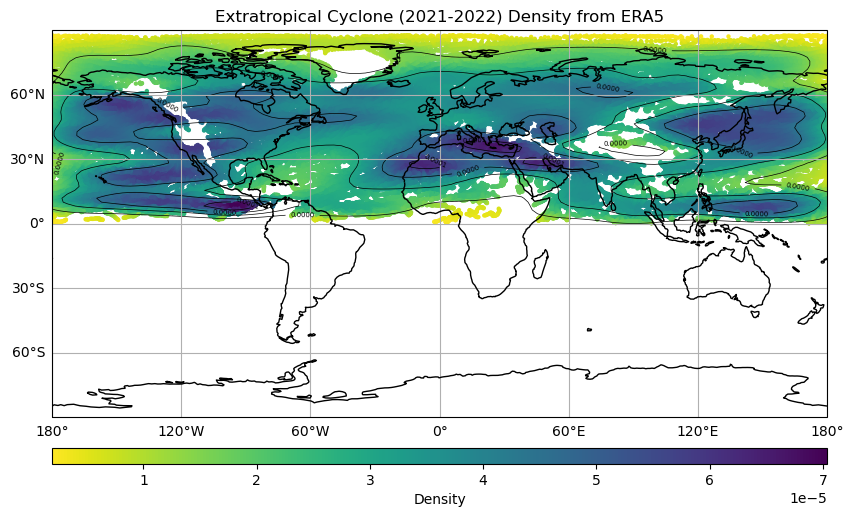

In [12]:
plot_density(trx_2122, 'vor', 'Extratropical Cyclone (2021-2022) Density from ERA5')

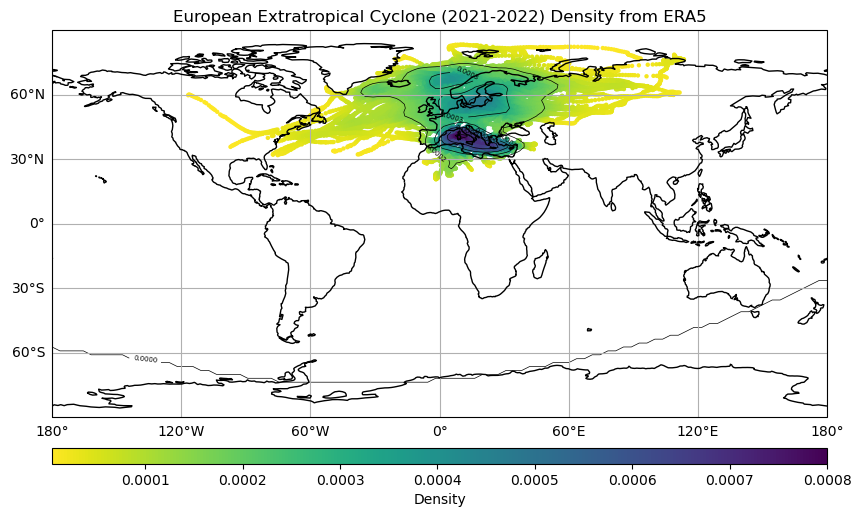

In [14]:
plot_density(trx_2122_europe, 'vor', 'European Extratropical Cyclone (2021-2022) Density from ERA5')

/tmp/ipykernel_504/2158023497.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180


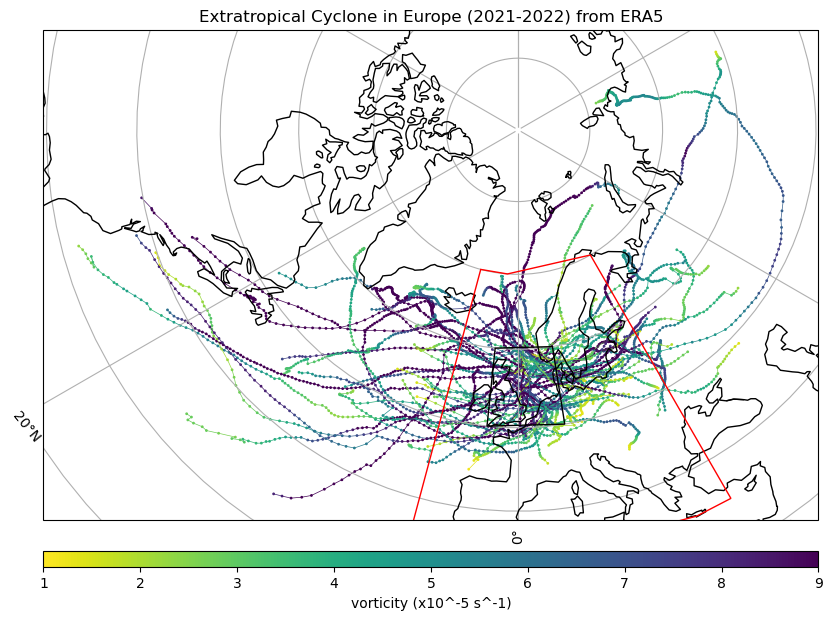

In [37]:
plot_track(trx_2122_europe, 'vor', 'Extratropical Cyclone in Europe (2021-2022) from ERA5')

/tmp/ipykernel_504/1134153711.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180


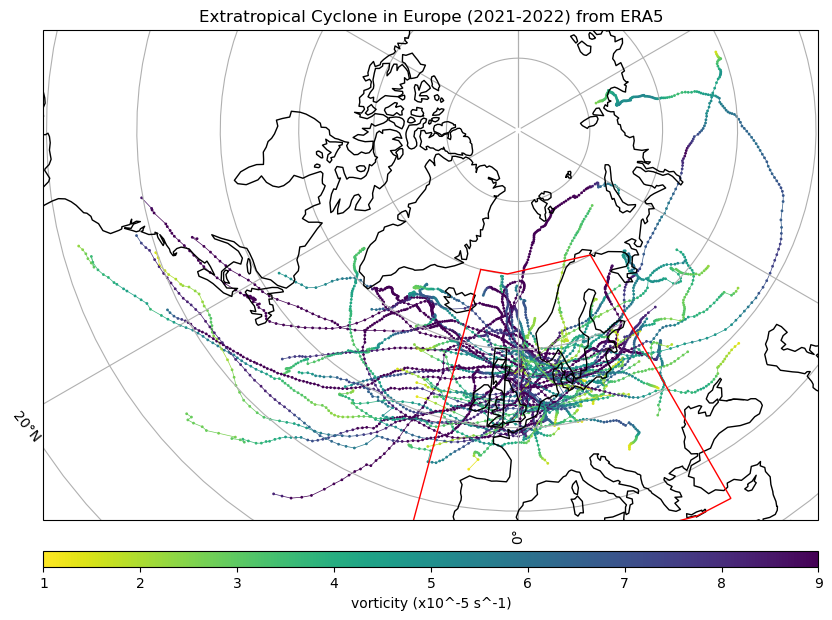

In [33]:
plot_track(trx_2122_europe_strong, 'vor', 'Extratropical Cyclone in Europe (2021-2022) from ERA5')

/tmp/ipykernel_11096/4119323652.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_2122_europe['lon_vor'] = ((trx_2122_europe['lon_vor'] + 180) % 360) - 180


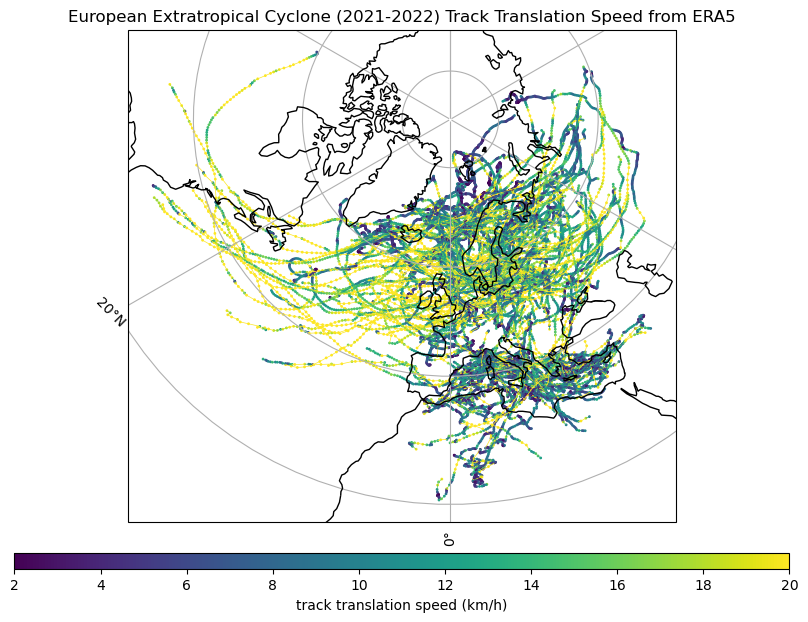

In [23]:
datacrs = ccrs.PlateCarree()
mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
trx_2122_europe['lon_vor'] = ((trx_2122_europe['lon_vor'] + 180) % 360) - 180

fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

cmap = plt.cm.viridis
norm = Normalize(2, 20)

# Processing each group
for name, group in trx_2122_europe.groupby('ID'):
    # Ensure the 'Speed' data is numeric and handle NaNs
    group['Speed'] = pd.to_numeric(group['Speed'], errors='coerce')
    group['Speed'].fillna(group['Speed'].mean(), inplace=True)

    points = group[['lon_vor', 'lat_vor']].values
    color_values = norm(group['Speed'].values)  # Normalize speed values
    colors = cmap(color_values)  # Convert normalized values to colors

    ax.scatter(group['lon_vor'], group['lat_vor'], color=colors, s=1, transform=datacrs)

    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        mid_value = norm((group['Speed'].iloc[i] + group['Speed'].iloc[i + 1]) / 2)
        ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                linewidth=0.5, transform=datacrs)

ax.set_title('European Extratropical Cyclone (2021-2022) Track Translation Speed from ERA5')
labelin = 'track translation speed (km/h)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
             orientation='horizontal', label=labelin)
plt.show()


## Filtering Storm and Closure 

In [10]:
closdata = pd.read_csv('northsea/closure_dates_window.csv')
closdata['Closure Dates'] = closdata['Closure Dates'].astype(str)
closdata['Window -2'] = closdata['Window -2'].astype(str)
closdata['Window +2'] = closdata['Window +2'].astype(str)
closdata['Closure Dates'] = pd.to_datetime(closdata['Closure Dates'], format='%d/%m/%Y')
closdata['Window -2'] = pd.to_datetime(closdata['Window -2'], format='%d/%m/%Y')
closdata['Window +2'] = pd.to_datetime(closdata['Window +2'], format='%d/%m/%Y', errors='coerce')
closdata

,Closure Number,Closure Dates,Window -2,Window +2
0,1,1983-02-01,1983-01-30,1983-02-03
1,2,1985-12-26,1985-12-24,1985-12-28
2,3,1987-03-29,1987-03-27,1987-03-31
3,4,1988-12-24,1988-12-22,1988-12-26
4,5,1990-02-12,1990-02-10,1990-02-14
...,...,...,...,...
216,217,2024-03-11,2024-03-09,2024-03-13
217,218,2024-03-14,2024-03-12,2024-03-16
218,219,2024-03-14,2024-03-12,2024-03-16
219,220,2024-04-08,2024-04-06,2024-04-10


In [12]:
closdata['Window -1'] = closdata['Closure Dates'] - pd.DateOffset(1)
closdata['Window +1'] = closdata['Closure Dates'] + pd.DateOffset(1)
closdata

,Closure Number,Closure Dates,Window -2,Window +2,Window -1,Window +1
0,1,1983-02-01,1983-01-30,1983-02-03,1983-01-31,1983-02-02
1,2,1985-12-26,1985-12-24,1985-12-28,1985-12-25,1985-12-27
2,3,1987-03-29,1987-03-27,1987-03-31,1987-03-28,1987-03-30
3,4,1988-12-24,1988-12-22,1988-12-26,1988-12-23,1988-12-25
4,5,1990-02-12,1990-02-10,1990-02-14,1990-02-11,1990-02-13
...,...,...,...,...,...,...
216,217,2024-03-11,2024-03-09,2024-03-13,2024-03-10,2024-03-12
217,218,2024-03-14,2024-03-12,2024-03-16,2024-03-13,2024-03-15
218,219,2024-03-14,2024-03-12,2024-03-16,2024-03-13,2024-03-15
219,220,2024-04-08,2024-04-06,2024-04-10,2024-04-07,2024-04-09


In [46]:
# Initialize an empty DataFrame to store the filtered results
filtered_trx = pd.DataFrame(columns=['date', 'ID', 'closure_ID', 'closure_date'])

# Ensure the 'date' column in trx_all is in datetime format
trx_all['date'] = pd.to_datetime(trx_all['date'])

# Iterate over each date window and filter the events
for _, row in closdata.iterrows():
    closure_id = row['Closure Number']
    closure_date = row['Closure Dates']
    start_date = pd.to_datetime(row['Window -2'])
    end_date = pd.to_datetime(row['Window +2'])

    # Filter events that have positions only inside this boundary 
    northsea_bound = trx_all[(trx_all['lon_vor'] >= -12) & (trx_all['lon_vor'] <= 12) & 
                             (trx_all['lat_vor'] >= 45) & (trx_all['lat_vor'] <= 65)]
    
    # Filter events that happen inside this boundary during the current date window
    valid_ids = northsea_bound[(northsea_bound['date'] >= start_date) & 
                               (northsea_bound['date'] <= end_date)]['ID'].unique()
    
    # Filter the original dataframe to get the final result
    trx_bound = trx_all[trx_all['ID'].isin(valid_ids)]
    filtered_window_trx = trx_bound[['date', 'ID']].copy()
    
    # Add the closure ID to the filtered events
    filtered_window_trx['closure_ID'] = closure_id
    filtered_window_trx['closure_date'] = closure_date
    
    # Concatenate the filtered results
    filtered_trx = pd.concat([filtered_trx, filtered_window_trx], ignore_index=True)

# Reset index of the filtered events DataFrame
filtered_trx.reset_index(drop=True, inplace=True)

# Display the filtered events
filtered_trx

,date,ID,closure_ID,closure_date
0,1983-01-23 07:00:00,17712,1,1983-02-01
1,1983-01-23 08:00:00,17712,1,1983-02-01
2,1983-01-23 09:00:00,17712,1,1983-02-01
3,1983-01-23 10:00:00,17712,1,1983-02-01
4,1983-01-23 11:00:00,17712,1,1983-02-01
...,...,...,...,...
24922,2022-02-22 16:00:00,25288,206,2022-02-21
24923,2022-02-22 17:00:00,25288,206,2022-02-21
24924,2022-02-22 18:00:00,25288,206,2022-02-21
24925,2022-02-22 19:00:00,25288,206,2022-02-21


In [47]:
print('all storm:', filtered_trx['ID'].nunique())

all storm: 123


In [48]:
filtered_ids = filtered_trx['ID'].unique()
trx_filterbyclos = trx_all[trx_all['ID'].isin(filtered_ids)]

trx_filterbyclos.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
6336,143452,1983-01-23 07:00:00,258.427002,49.398632,1.690920,255.2196,44.93248,1007.834,260.7188,43.70022,...,52.97422,4.471160,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,43.296328,12.026758,28.361865
6337,143453,1983-01-23 08:00:00,258.712341,49.740837,1.806277,NaN,NaN,1012.883,251.7188,52.97422,...,52.97422,4.597179,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,21.353715,5.931588,42.305112
6338,143454,1983-01-23 09:00:00,258.912323,49.882652,1.894147,NaN,NaN,1012.730,251.7188,52.97422,...,52.97422,4.648538,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,186.789005,51.885835,167.888273
6339,143455,1983-01-23 10:00:00,259.439880,48.239216,2.225054,259.7789,47.66829,1010.700,254.5312,43.41919,...,43.41919,9.134160,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,24.085116,6.690310,39.952441
6340,143456,1983-01-23 11:00:00,259.648773,48.405067,2.264972,NaN,NaN,1010.796,252.8438,52.41216,...,43.70022,7.310028,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,25.641530,7.122647,56.336624


In [57]:
def plot_track_2(data_trx, filtered_trx):
    '''
    Plot storm tracks on a map.

    Parameters:
    data : DataFrame containing the storm track data.
    var : str, one of 'vor', 'wind', 'mslp' indicating the variable to be plotted.
    fig_title : str, the title of the figure.
    '''    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['ID'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis
    norm = Normalize(2, 20)

    # Processing each group
    for name, group in data_trx.groupby('ID'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group['speed'] = pd.to_numeric(group['speed'], errors='coerce')
        group['speed'].fillna(group['speed'].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group['speed'].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors

        # Find the 'closure_ID' from id_match data, which can be found in the same rows as 'ID' in it
        closure_ids = filtered_trx[filtered_trx['ID'] == name]['closure_ID'].unique()
        print('closure id:', closure_ids)
        # Find dates corresponding to these closure_ids in data_closure
        closure_dates = filtered_trx[filtered_trx['closure_ID'].isin(closure_ids)]['closure_date'].unique()
        print('closure date:', closure_dates)
        
        # Find positions where the date matches with the closure dates
        matching_positions = group[group['date'].isin(closure_dates)][['lon_vor', 'lat_vor']].head(1).values
        
        # Plot the matching positions with a distinct marker
        for pos in matching_positions:
            ax.plot(pos[0], pos[1], '*', markersize=3, color='tab:red', transform=datacrs)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['speed'].iloc[i] + group['speed'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.5, transform=datacrs)

    #ax.set_title(f'Extratropical Cyclone in North Sea {season} (n={n_storm})')
    ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window (n={n_storm})")
    labelin = 'track propagation speed (km/h)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()


closure id: [179]
closure date: <DatetimeArray>
['2017-10-05 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [179]
closure date: <DatetimeArray>
['2017-10-05 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [10]
closure date: <DatetimeArray>
['1990-10-07 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [30]
closure date: <DatetimeArray>
['1996-10-29 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [200]
closure date: <DatetimeArray>
['2021-10-21 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [30]
closure date: <DatetimeArray>
['1996-10-29 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [33]
closure date: <DatetimeArray>
['1998-11-06 00:00:00']
Length: 1, dtype: datetime64[ns]
closure id: [104 105]
closure date: <DatetimeArray>
['2007-11-08 00:00:00', '2007-11-09 00:00:00']
Length: 2, dtype: datetime64[ns]
closure id: [104 105]
closure date: <DatetimeArray>
['2007-11-08 00:00:00', '2007-11-09 00:00:00']
Length: 2, dtype: datetime64[ns]
closu

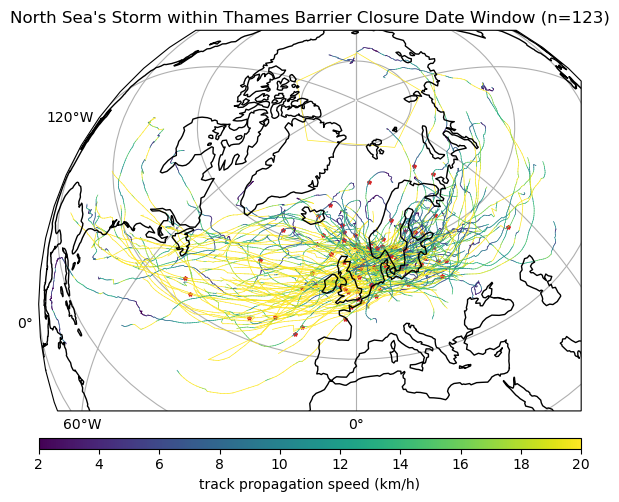

In [58]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_2(trx_filterbyclos, filtered_trx)

In [59]:
def plot_track_2(data_trx, filtered_trx):
    '''
    Plot storm tracks on a map.

    Parameters:
    data : DataFrame containing the storm track data.
    var : str, one of 'vor', 'wind', 'mslp' indicating the variable to be plotted.
    fig_title : str, the title of the figure.
    '''    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx = data_trx[data_trx['season'] == '2013-2014']
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['ID'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis
    norm = Normalize(2, 20)

    # Processing each group
    for name, group in data_trx.groupby('ID'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group['speed'] = pd.to_numeric(group['speed'], errors='coerce')
        group['speed'].fillna(group['speed'].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group['speed'].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors

        # Find the 'closure_ID' from id_match data, which can be found in the same rows as 'ID' in it
        closure_ids = filtered_trx[filtered_trx['ID'] == name]['closure_ID'].unique()
        # Find dates corresponding to these closure_ids in data_closure
        closure_dates = filtered_trx[filtered_trx['closure_ID'].isin(closure_ids)]['closure_date'].unique()
        
        # Find positions where the date matches with the closure dates
        matching_positions = group[group['date'].isin(closure_dates)][['lon_vor', 'lat_vor']].head(1).values
        
        # Plot the matching positions with a distinct marker
        for pos in matching_positions:
            ax.plot(pos[0], pos[1], '*', markersize=3, color='tab:red', transform=datacrs)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['speed'].iloc[i] + group['speed'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.5, transform=datacrs)

    #ax.set_title(f'Extratropical Cyclone in North Sea {season} (n={n_storm})')
    ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window (n={n_storm})")
    labelin = 'track propagation speed (km/h)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()


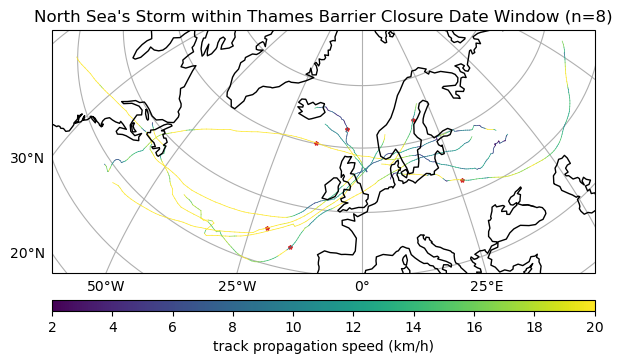

In [60]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_2(trx_filterbyclos, filtered_trx)

## Open ERA5_VOR850 combined 1980-2022

In [35]:
import pandas as pd

# Sample DataFrame
data = {
    'time': ['2024-06-27 08:00:00', '2024-06-27 09:00:00', '2024-06-27 08:00:00', '2024-06-27 09:00:00', '2024-06-27 10:00:00'],
    'track_id': [1, 1, 2, 2, 2],
    'lat': [40.7128, 40.7130, 34.0522, 34.0525, 34.0528],
    'lon': [-74.0060, -74.0058, -118.2437, -118.2435, -118.2433]
}

df = pd.DataFrame(data)

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Calculate the duration for each track_id
duration_df = df.groupby('track_id')['time'].agg(['min', 'max'])
duration_df['duration'] = duration_df['max'] - duration_df['min']

# Filter out track_ids with duration less than 1.5 hours
filtered_duration_df = duration_df[duration_df['duration'] >= pd.Timedelta(hours=2)]

# Merge the filtered duration back into the original DataFrame
filtered_df = df.merge(filtered_duration_df['duration'], on='track_id', how='inner')

# Display the filtered DataFrame with the new duration column
print(filtered_df)


                 time  track_id      lat       lon        duration
0 2024-06-27 08:00:00         2  34.0522 -118.2437 0 days 02:00:00
1 2024-06-27 09:00:00         2  34.0525 -118.2435 0 days 02:00:00
2 2024-06-27 10:00:00         2  34.0528 -118.2433 0 days 02:00:00


In [36]:
filtered_df

,time,track_id,lat,lon,duration
0,2024-06-27 08:00:00,2,34.0522,-118.2437,0 days 02:00:00
1,2024-06-27 09:00:00,2,34.0525,-118.2435,0 days 02:00:00
2,2024-06-27 10:00:00,2,34.0528,-118.2433,0 days 02:00:00


In [5]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind925', 'lat_wind925', 'var_wind925', 'lon_wind10m', 'lat_wind10m', 'var_wind10m',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

for iyear in range(1970,1979,1):
    filename = fpath + f'ERA5_VOR850_1hr_oct-mar{iyear}{iyear+1}_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
    trx = read_tracks(filename, var_names)
    trx = to_datetime(trx)
    trx['season'] = trx['start_time'].apply(get_season)

    filtered_trx = trx[(trx['lon_vor'] >= -6) & (trx['lon_vor'] <= 9) & 
                       (trx['lat_vor'] >= 50) & (trx['lat_vor'] <= 60) &
                       (trx['var_wind'] >= 25)]
    
    valid_ids = filtered_trx['ID'].unique()
    trx_europe_strong = trx[trx['ID'].isin(valid_ids)]

    trx_europe_strong.to_csv(f'Track/ERA5_VOR850_1hr_oct-mar{iyear}{iyear+1}_NORTHSEA.csv')

In [9]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

for iyear in range(1970,1980,1):
    filename = fpath + f'ERA5_VOR850_1hr_oct-mar{iyear}{iyear+1}_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
    trx = read_tracks(filename, var_names)
    trx = to_datetime(trx)
    trx['season'] = trx['start_time'].apply(get_season)

    # Filter for records within the lon_vor and lat_vor boundaries
    filtered_trx_boundary = trx[(trx['lon_vor'] >= -6) & (trx['lon_vor'] <= 9) & 
                                (trx['lat_vor'] >= 50) & (trx['lat_vor'] <= 60)]
    
    # Get IDs of tracks where minimum var_wind is >= 25 within the boundary
    valid_ids = filtered_trx_boundary.groupby('ID').filter(lambda x: x['var_wind'].min() >= 25)['ID'].unique()
    # Filter the original dataframe to get the final result
    trx_strong = trx[trx['ID'].isin(valid_ids)]

    # Filter out short lived vorticity
    trx_strong['date'] = pd.to_datetime(trx_strong['date'])

    # Calculate the duration for each track_id
    duration = trx_strong.groupby('ID')['date'].agg(['min', 'max'])
    duration['duration'] = duration['max'] - duration['min']

    # Filter out track_ids with duration less than 1.5 hours
    filtered_duration_df = duration[duration['duration'] >= pd.Timedelta(hours=48)]

    # Merge the filtered duration back into the original DataFrame
    trx_strong_longlive = trx_strong.merge(filtered_duration_df['duration'], on='ID', how='inner')
    
    trx_strong_longlive.to_csv(f'Track/ERA5_VOR850_1hr_oct-mar{iyear}{iyear+1}_NORTHSEA_minwindspeed25_longlive.csv')


/tmp/ipykernel_835/3990085324.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  valid_ids = filtered_trx_boundary.groupby('ID').filter(lambda x: x['var_wind'].min() >= 25)['ID'].unique()
/tmp/ipykernel_835/3990085324.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_strong['date'] = pd.to_datetime(trx_strong['date'])
/tmp/ipykernel_835/3990085324.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

In [39]:
trx_all = pd.DataFrame()

for i in range(1982, 2022):
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25_longlive.csv'
    trx_data = pd.read_csv(file_path)
    trx_all = pd.concat([trx_all, trx_data], ignore_index=True)
    
trx_all.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,40.63476,3.37500,61.96718,20.57130,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,39.33882,3.93750,62.81027,20.07453,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,35.92666,4.21875,63.37233,18.02655,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,32.58338,4.50000,61.96718,18.71960,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,30.18725,5.06250,62.24821,17.47002,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00


In [40]:
print('all storm:', trx_all['ID'].nunique())
#print('2013-2014 storm:', trx_1314['ID'].nunique())

# Drop duplicates based on the combination of 'ID' and 'season'
unique_storms = trx_all.drop_duplicates(subset=['ID', 'season'])

# Print the unique rows where 'ID' and 'season' columns combined are unique
#print('Unique rows (ID and season):')
#print(unique_storms)

print('Number of unique storms (ID and season):', unique_storms.shape[0])


all storm: 644
Number of unique storms (ID and season): 652


/tmp/ipykernel_685/4020369924.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180


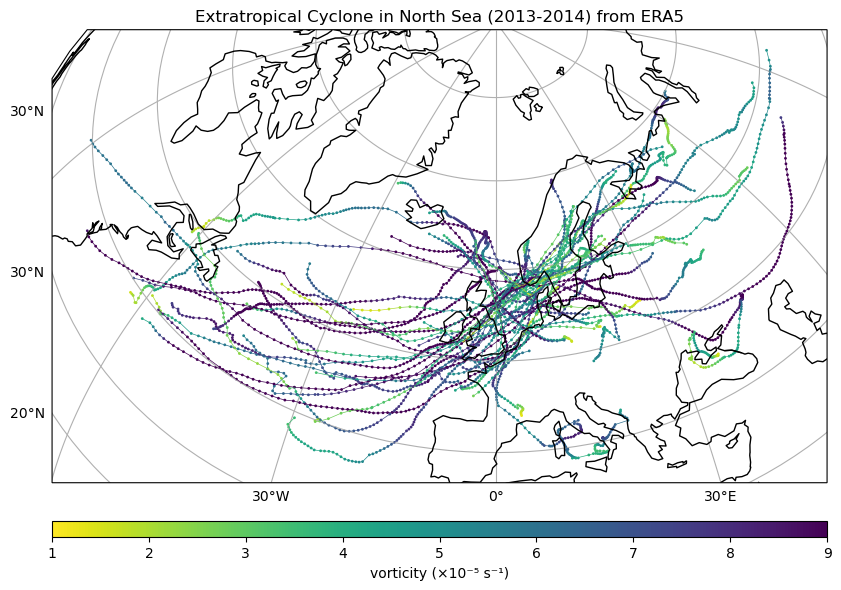

In [35]:
plot_track(trx_1314, 'vor', 'Extratropical Cyclone in North Sea (2013-2014) from ERA5')

In [13]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-70, 60, 90, 40]

fig, axs = plt.subplots(7, 6, sharey=True, sharex=True, figsize=(18., 20.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

trx_all['lon_vor'] = ((trx_all['lon_vor'] + 180) % 360) - 180
trx_all['speed'] = pd.to_numeric(trx_all['speed'], errors='coerce')
trx_all['speed'].fillna(trx_all['speed'].mean(), inplace=True)

for iyear, ax in enumerate(axs):
    year = 1980 + iyear
    trx_season = trx_all[trx_all['season'] == f'{year}-{year+1}']
    if trx_season.empty:
        continue

    season = trx_season['season'].iloc[0]
    n_storm = trx_season['ID'].nunique()

    ax.set_extent(boundary, crs=datacrs)
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)

    cmap = plt.cm.viridis
    norm = Normalize(2, 20)

    points = trx_season[['lon_vor', 'lat_vor']].values
    color_values = norm(trx_season['speed'].values)
    colors = cmap(color_values)

    #ax.scatter(trx_season['lon_vor'], trx_season['lat_vor'], color=colors, s=1, transform=datacrs)

    for idx, group in trx_season.groupby('ID'):
        points = group[['lon_vor', 'lat_vor']].values
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['speed'].iloc[i] + group['speed'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.8, transform=datacrs)

    ax.set_title(f'{season} (n={n_storm})', fontsize=9)

#fig.subplots_adjust(bottom=0.1, right=0.8, top=0.9, wspace=0.08, hspace=0.09)
fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.05)
cax = fig.add_axes([0.82, 0.15, 0.02, 0.75])
labelin = 'track translation speed (km/h)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50,
             orientation='vertical', label=labelin)

plt.show()


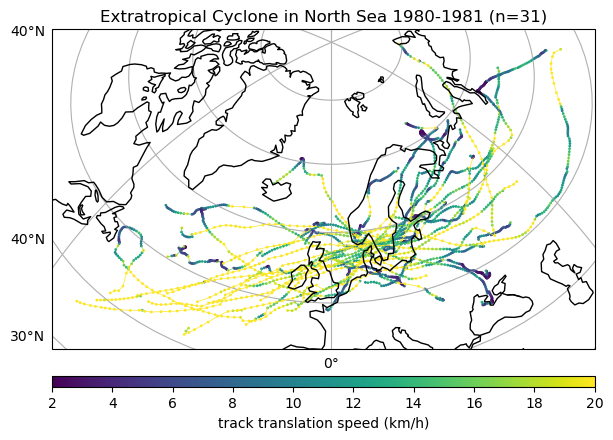

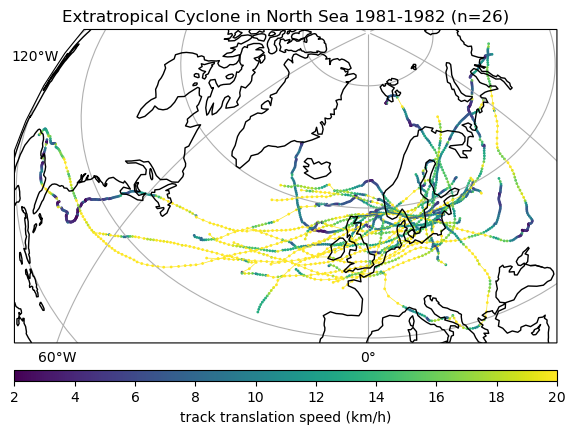

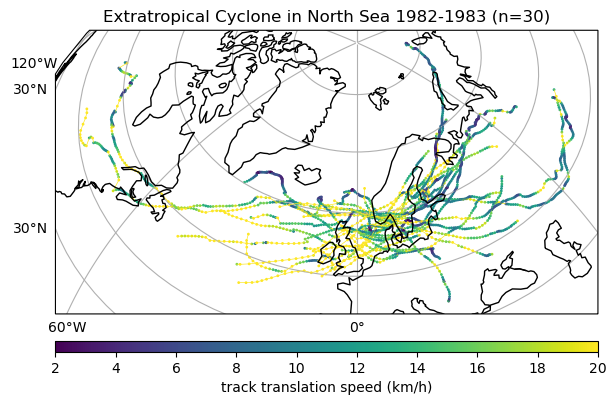

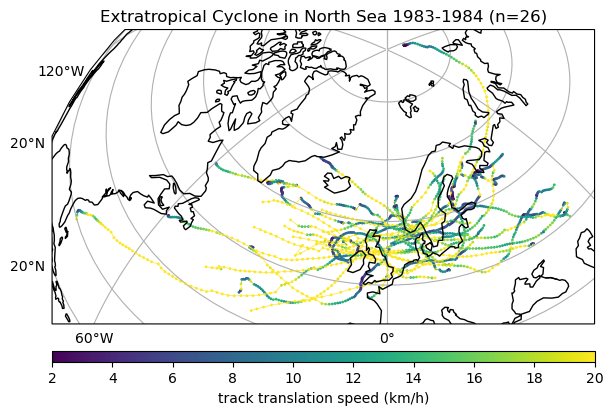

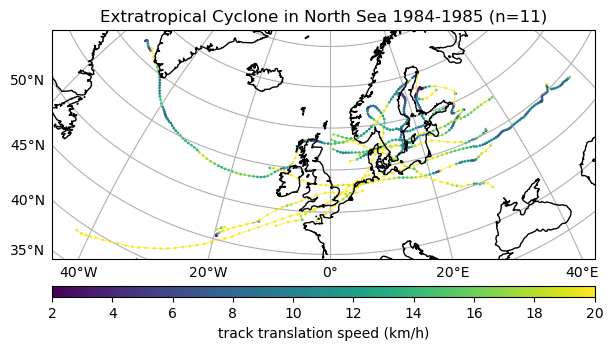

...

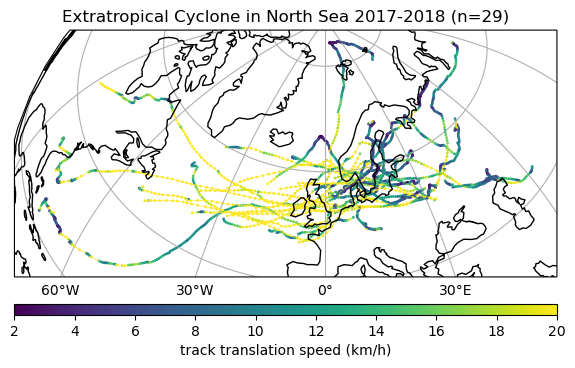

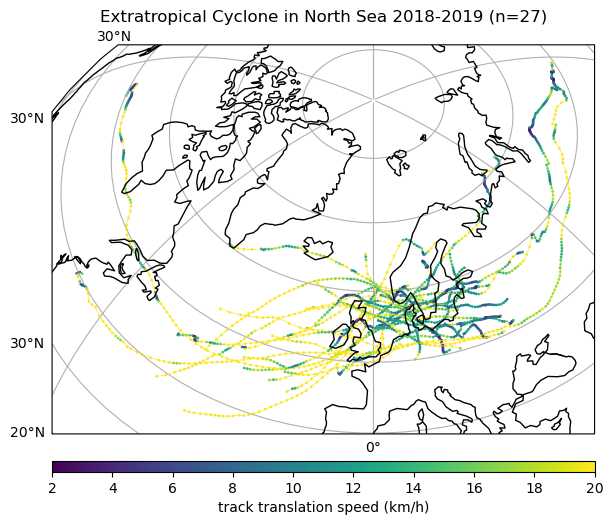

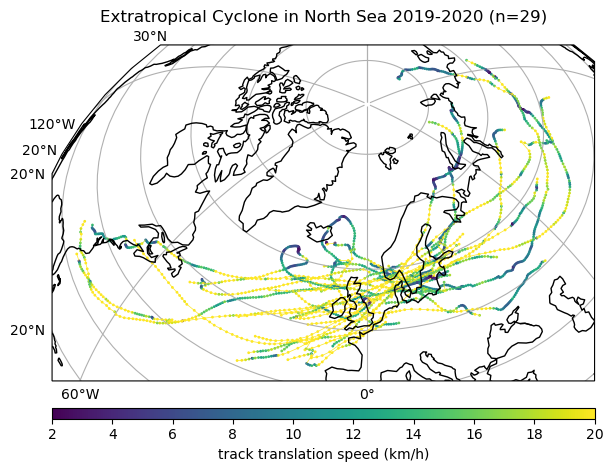

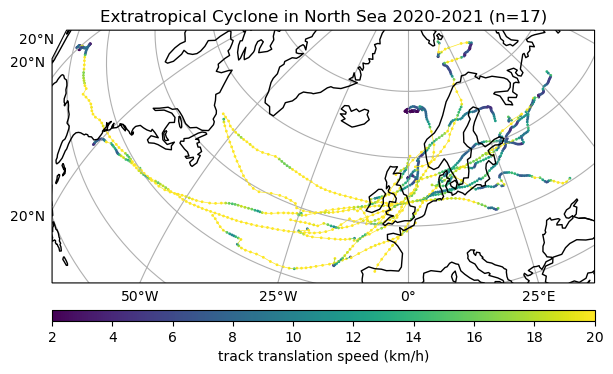

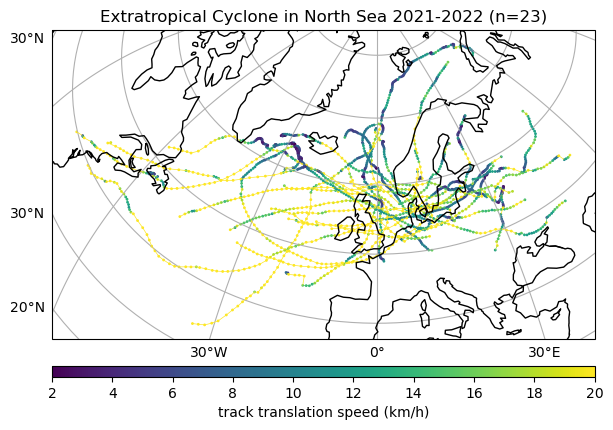

In [48]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)


for iyear in range(1980, 2022, 1):
    trx_season = trx_all[trx_all['season'] == f'{iyear}-{iyear+1}']
    plot_track_wind_season(trx_season)

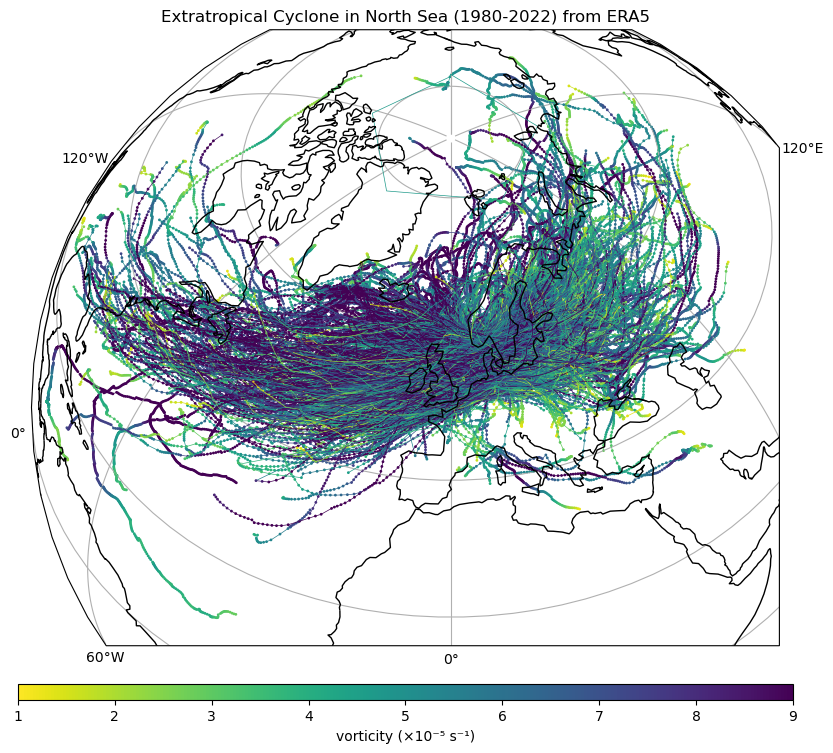

In [10]:
plot_track(trx_all, 'vor', 'Extratropical Cyclone in North Sea (1982-2022) from ERA5')

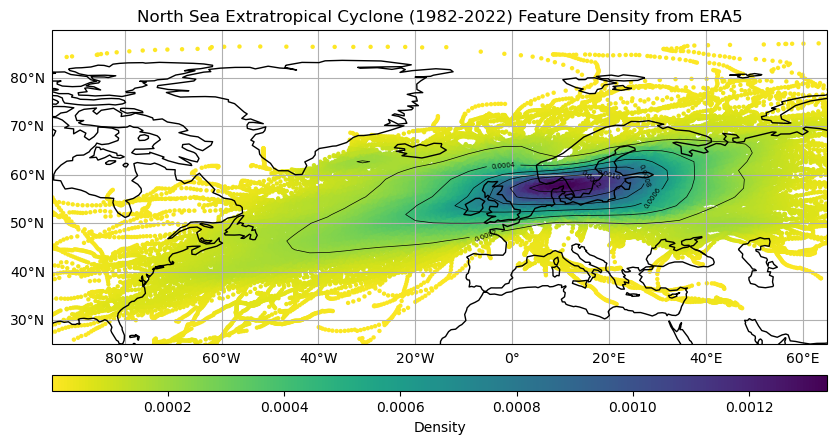

In [41]:
plot_density(trx_all, 'vor', 'North Sea Extratropical Cyclone (1982-2022) Feature Density from ERA5')

## Calculate storm track direction & speed

In [7]:
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [8]:
trx_all = calc_speed_dir(trx_all, 1)
trx_all['bearing'] = trx_all['bearing'].apply(adjust_bearing)
trx_all.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
0,21998,1980-10-18 09:00:00,6.904566,59.261848,9.275548,8.139204,57.70463,983.7514,3.65625,62.24821,...,61.96718,19.69722,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,36.769454,10.213737,232.513364
1,21999,1980-10-18 10:00:00,6.396044,59.059975,9.672718,8.221525,57.83183,983.9997,1.96875,58.59482,...,62.52924,19.92188,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,31.370896,8.714138,353.610852
2,22000,1980-10-18 11:00:00,6.334700,59.339821,9.957471,8.327487,57.96751,984.2194,3.37500,62.52924,...,62.52924,20.21957,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,27.919293,7.755359,349.803822
3,22001,1980-10-18 12:00:00,6.247219,59.586449,10.169360,8.412743,58.10663,984.5703,3.09375,62.24821,...,62.52924,20.36220,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,14.213870,3.948297,345.937542
4,22002,1980-10-18 13:00:00,6.185861,59.710197,10.413090,8.476355,58.27464,984.8670,3.65625,62.24821,...,62.24821,20.45578,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,2.542488,0.706247,334.407357


/tmp/ipykernel_555/1266460935.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  group['speed'].fillna(group['speed'].mean(), inplace=True)
/tmp/ipykernel_555/1266460935.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

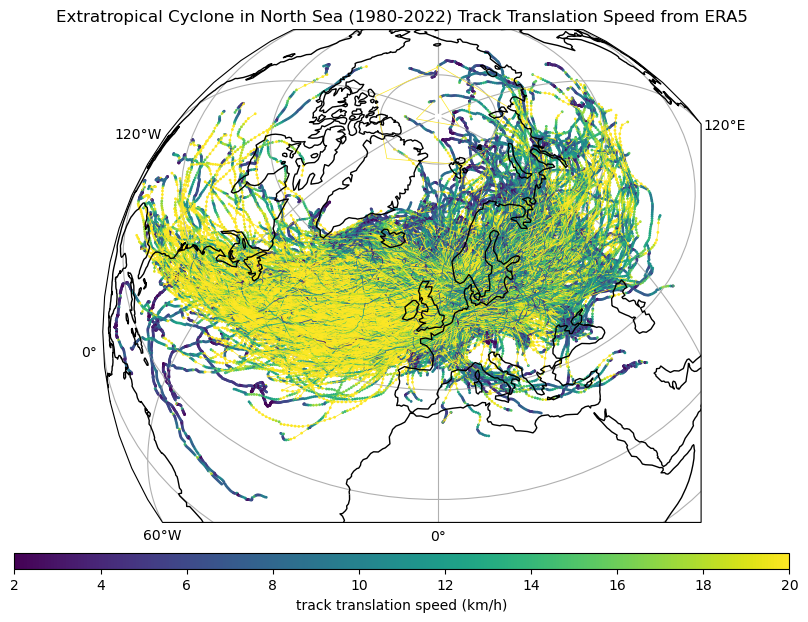

In [8]:
datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
trx_all['lon_vor'] = ((trx_all['lon_vor'] + 180) % 360) - 180

fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

cmap = plt.cm.viridis
norm = Normalize(2, 20)

# Processing each group
for name, group in trx_all.groupby('ID'):
    # Ensure the 'Speed' data is numeric and handle NaNs
    group['speed'] = pd.to_numeric(group['speed'], errors='coerce')
    group['speed'].fillna(group['speed'].mean(), inplace=True)

    points = group[['lon_vor', 'lat_vor']].values
    color_values = norm(group['speed'].values)  # Normalize speed values
    colors = cmap(color_values)  # Convert normalized values to colors

    ax.scatter(group['lon_vor'], group['lat_vor'], color=colors, s=1, transform=datacrs)

    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        mid_value = norm((group['speed'].iloc[i] + group['speed'].iloc[i + 1]) / 2)
        ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                linewidth=0.5, transform=datacrs)

ax.set_title('Extratropical Cyclone in North Sea (1980-2022) Track Translation Speed from ERA5')
labelin = 'track translation speed (km/h)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
             orientation='horizontal', label=labelin)
plt.show()


<Figure size 500x500 with 0 Axes>

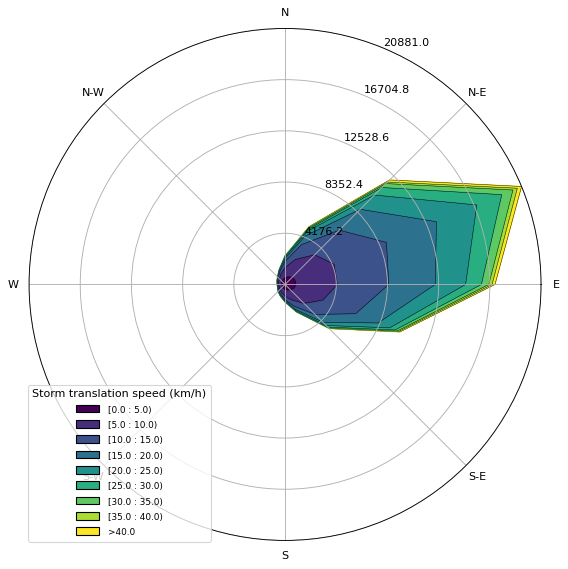

In [52]:
from windrose import WindroseAxes
trx_direction = trx_all.dropna(subset=['bearing', 'speed'])

fig = plt.figure(figsize=(5., 5.))
ax = WindroseAxes.from_ax()
ax.contourf(trx_direction['bearing'].values, trx_direction['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.viridis)
ax.contour(trx_direction['bearing'].values, trx_direction['speed'].values, bins=np.arange(0, 45, 5), colors='black', linewidth=0.4)
ax.set_legend(title="Storm translation speed (km/h)", loc="lower left")

In [53]:
northsea_bound = trx_all[(trx_all['lon_vor'] >= -4) & (trx_all['lon_vor'] <= 10) & 
                      (trx_all['lat_vor'] >= 50) & (trx_all['lat_vor'] <= 60)]
northsea_bound.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
0,21998,1980-10-18 09:00:00,6.904566,59.261848,9.275548,8.139204,57.70463,983.7514,3.65625,62.24821,...,61.96718,19.69722,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,36.769454,10.213737,232.513364
1,21999,1980-10-18 10:00:00,6.396044,59.059975,9.672718,8.221525,57.83183,983.9997,1.96875,58.59482,...,62.52924,19.92188,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,31.370896,8.714138,353.610852
2,22000,1980-10-18 11:00:00,6.334700,59.339821,9.957471,8.327487,57.96751,984.2194,3.37500,62.52924,...,62.52924,20.21957,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,27.919293,7.755359,349.803822
3,22001,1980-10-18 12:00:00,6.247219,59.586449,10.169360,8.412743,58.10663,984.5703,3.09375,62.24821,...,62.52924,20.36220,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,14.213870,3.948297,345.937542
4,22002,1980-10-18 13:00:00,6.185861,59.710197,10.413090,8.476355,58.27464,984.8670,3.65625,62.24821,...,62.24821,20.45578,2470,1980-10-18 09:00:00,NaN,unknown,1980-1981,2.542488,0.706247,334.407357


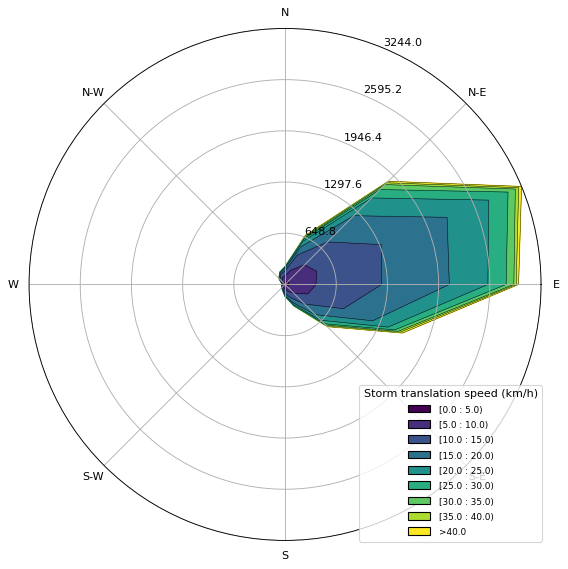

In [54]:
trx_direction_north = northsea_bound.dropna(subset=['bearing', 'speed'])
ax = WindroseAxes.from_ax()
ax.contourf(trx_direction_north['bearing'].values, trx_direction_north['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.viridis)
ax.contour(trx_direction_north['bearing'].values, trx_direction_north['speed'].values, bins=np.arange(0, 45, 5), colors='black', linewidth=0.4)
ax.set_legend(title="Storm translation speed (km/h)", loc="lower right")
plt.show()

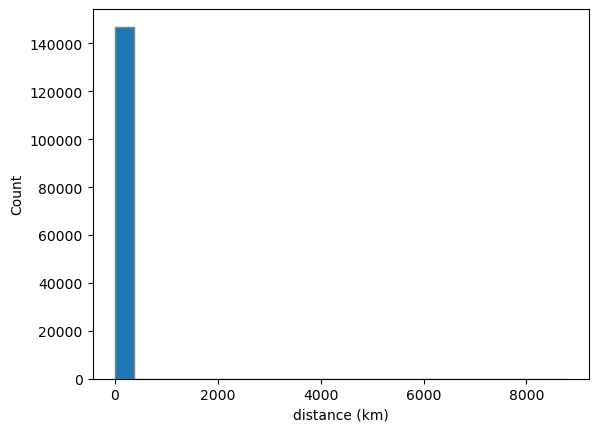

In [14]:
dist = pd.to_numeric(trx_all['distance'], errors='coerce')

dist.plot(kind='hist', bins=24, color='tab:blue', edgecolor='grey')
plt.xlabel('distance (km)')
plt.ylabel('Count')
plt.show()

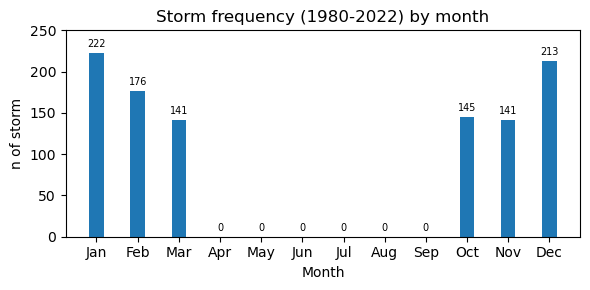

In [57]:
sta_month = trx_all['start_time'].dropna().unique()
sta_month = pd.to_datetime(sta_month)
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6., 3.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

bars = ax.bar(months, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='tab:blue')

ax.set_title('Storm frequency (1980-2022) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_ylim(0, 250)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
for bar in bars:
   height = bar.get_height()
   ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
   textcoords="offset points", ha='center', va='bottom', size=7)

#ax.legend(loc='upper right')

#plt.grid(True)
plt.tight_layout()
plt.show()

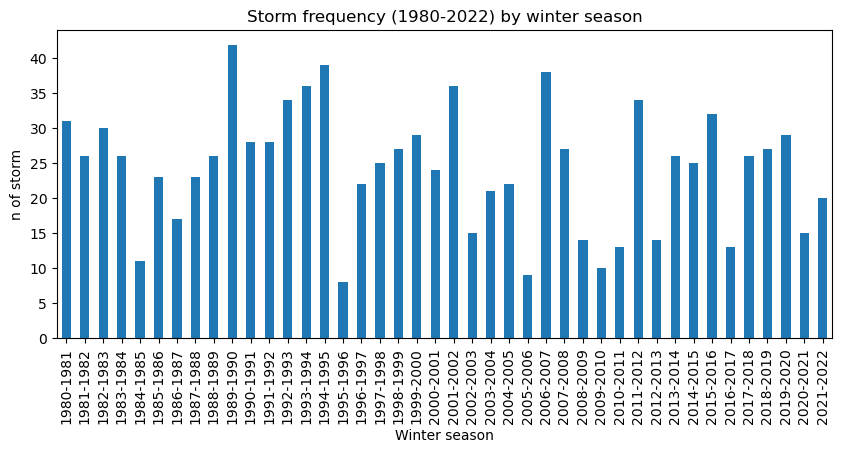

In [58]:
trx_drop = trx_all.drop_duplicates(subset=['ID'])
season_counts = trx_drop['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1980-2022) by winter season')
plt.xlabel('Winter season')
plt.ylabel('n of storm')
plt.xticks(rotation=90)

#plt.grid(True)
plt.show()

#print("\nCounts per Season:")
#print(season_counts)

In [6]:
path = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
output_file =  'merged_track.txt' 

with open(output_file, 'w') as outfile:
    for i in range(1980, 2022):
        syear = i
        eyear = i + 1
        filename = path + f'ERA5_VOR850_1hr_oct-mar{syear}{eyear}_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
        with open(filename, 'r') as infile:
            outfile.write(infile.read())

In [6]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_5 = read_tracks('merged_track.txt', var_names)
trx_5 = to_datetime(trx_5)
trx_5['season'] = trx_5['start_time'].apply(get_season)
#trx = add_wrap_id(trx)
trx_5

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
0,1980-10-01 00:00:00,339.492126,33.568161,7.810895,339.1625,33.05409,1010.4920,345.6562,36.67446,19.87061,345.9375,36.39343,11.82803,10,1980-10-01 00:00:00,NaT,,1980-1981
1,1980-10-01 01:00:00,339.481232,33.770161,7.839233,338.9977,33.05897,1010.6600,346.2188,36.11240,20.48640,346.2188,35.83137,13.64472,10,1980-10-01 00:00:00,NaT,,1980-1981
2,1980-10-01 02:00:00,339.453674,33.978741,7.866363,339.0632,33.14759,1010.8860,345.6562,36.95549,22.16590,345.9375,36.67446,14.23902,10,1980-10-01 00:00:00,NaT,,1980-1981
3,1980-10-01 03:00:00,339.441986,34.200703,7.890915,339.0608,33.28640,1010.6940,345.3750,37.79858,22.74866,345.3750,37.23652,13.59618,10,1980-10-01 00:00:00,NaT,,1980-1981
4,1980-10-01 04:00:00,339.416016,34.423767,7.939483,338.9775,33.45113,1010.4100,344.8125,38.36064,20.36135,344.8125,37.23652,12.26464,10,1980-10-01 00:00:00,NaT,,1980-1981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9355752,2022-03-31 19:00:00,253.281281,52.871670,7.739974,253.5049,52.59162,997.0352,259.5938,53.53628,15.83161,251.1562,50.72598,11.71049,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355753,2022-03-31 20:00:00,253.482239,52.941093,7.732875,253.7769,52.77341,997.3657,259.5938,53.53628,16.72056,251.4375,51.28803,11.48367,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355754,2022-03-31 21:00:00,253.707535,53.047001,7.692232,254.0683,52.85543,997.1564,259.5938,53.53628,17.28619,251.7188,51.85009,11.25157,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355755,2022-03-31 22:00:00,253.935608,53.155842,8.065690,254.2411,52.98973,996.6360,259.5938,53.53628,17.38802,253.1250,50.44494,12.57074,32623,2022-03-30 21:00:00,NaT,,2021-2022


In [10]:
trx_5['ID'].nunique()

30184

## ERA20C European Storm Track from CEDA

In [6]:
fpath = '/badc/deposited2018/robust-storm-track/data/era-20c/'
filename = fpath + 'ERA20C_tr_trs_VOR850_19802009_pos.addmslp_addspeed_addprecip_addomega_addlandwinds_addavgprecip.new_1000km2dayfiltered_RealProjregion2filtered_maxlandwindsinregion.txt'

with open(filename, 'r') as file:
    for i in range(8):
        print(file.readline().strip())

0
PER_INFO 1    180.00000
0 0
TRACK_NUM      1290 ADD_FLD    6  16 &111110
TRACK_ID  10 START_TIME 1980100100
POINT_NUM  85
1980100100 276.477875 32.726715 3.683265e+00 & 2.782872e+02 & 3.083150e+01 & 1.006408e+03 & 2.812500e+02 & 3.543850e+01 & 1.605729e+01 & 2.777344e+02 & 3.192976e+01 & 9.663895e-01 & 2.819531e+02 & 3.403502e+01 & -4.610014e-01 & 2.812500e+02 & 3.543850e+01 & 1.605729e+01 & 4.589758e-01 &
1980100103 276.621796 32.233791 3.502314e+00 & 2.769048e+02 & 3.058227e+01 & 1.005997e+03 & 2.819531e+02 & 3.614030e+01 & 1.649195e+01 & 2.756250e+02 & 2.982450e+01 & 1.212914e+00 & 2.819531e+02 & 3.403502e+01 & -3.588240e-01 & 2.819531e+02 & 3.614030e+01 & 1.649195e+01 & 4.290368e-01 &


In [10]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_20c = read_tracks(filename, var_names)
trx_20c = to_datetime(trx_20c)
trx_20c['season'] = trx_20c['start_time'].apply(get_season)
#trx = add_wrap_id(trx)
trx_20c

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,...,var_ver,lon_wind_sca,lat_wind_sca,var_wind_sca,prec5deg,ID,start_time,median_time,name,season
0,1980-10-01 00:00:00,276.477875,32.726715,3.683265,278.28720,30.83150,1006.408,281.2500,35.4385,16.05729,...,-0.461001,281.2500,35.4385,16.05729,0.458976,10,1980-10-01 00:00:00,NaT,,1980-1981
1,1980-10-01 03:00:00,276.621796,32.233791,3.502314,276.90480,30.58227,1005.997,281.9531,36.1403,16.49195,...,-0.358824,281.9531,36.1403,16.49195,0.429037,10,1980-10-01 00:00:00,NaT,,1980-1981
2,1980-10-01 06:00:00,276.667175,31.761646,3.099555,NaN,NaN,1007.540,281.2500,35.4385,17.06239,...,-0.238685,281.2500,35.4385,17.06239,0.430904,10,1980-10-01 00:00:00,NaT,,1980-1981
3,1980-10-01 09:00:00,276.765594,31.485422,3.484782,NaN,NaN,1007.055,280.5469,34.7368,15.26498,...,-0.416270,280.5469,34.7368,15.26498,0.317605,10,1980-10-01 00:00:00,NaT,,1980-1981
4,1980-10-01 12:00:00,277.338654,31.542223,3.316391,NaN,NaN,1008.109,284.0625,30.5263,13.23500,...,-0.350605,279.8438,34.7368,13.20241,0.325036,10,1980-10-01 00:00:00,NaT,,1980-1981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48539,2010-03-31 09:00:00,75.058159,63.905251,3.939470,76.44798,63.91080,1011.411,82.9688,62.8068,13.24518,...,-0.230447,82.9688,62.8068,13.24518,0.134497,7060,2010-03-25 21:00:00,NaT,,2009-2010
48540,2010-03-31 12:00:00,77.052773,63.329147,3.912337,76.74723,64.04748,1009.522,76.6406,57.8946,14.09756,...,-0.284631,76.6406,57.8946,14.09756,0.145633,7060,2010-03-25 21:00:00,NaT,,2009-2010
48541,2010-03-31 15:00:00,78.209328,63.829582,4.370348,78.89957,63.53005,1011.414,86.4844,63.5086,15.12425,...,-0.250300,86.4844,63.5086,15.12425,0.135716,7060,2010-03-25 21:00:00,NaT,,2009-2010
48542,2010-03-31 18:00:00,79.054199,64.184853,4.157902,78.83983,63.92422,1008.993,87.1875,64.2103,13.95099,...,-0.210946,87.1875,64.2103,13.95099,0.106958,7060,2010-03-25 21:00:00,NaT,,2009-2010


In [11]:
trx_20c['ID'].nunique()

1181

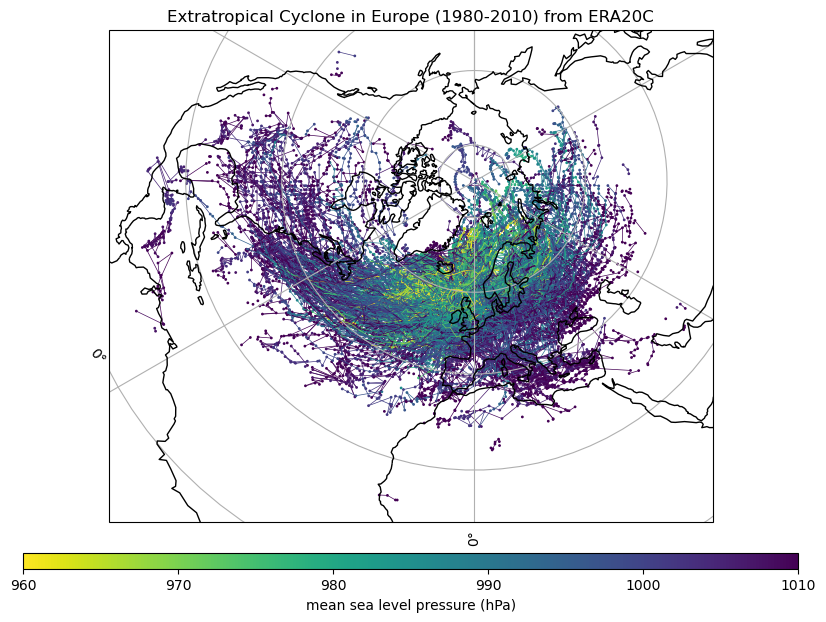

In [29]:
plot_track(trx_20c, 'mslp', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

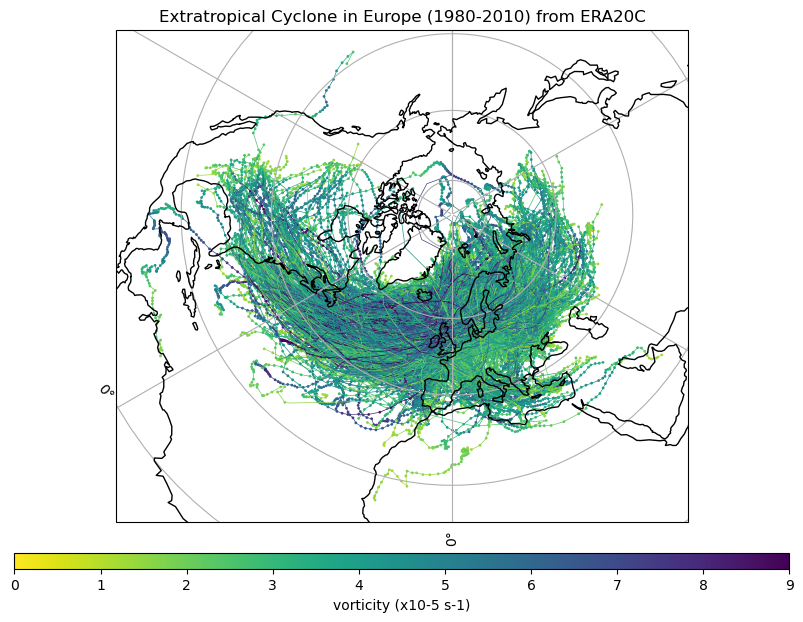

In [30]:
plot_track(trx_20c, 'vor', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

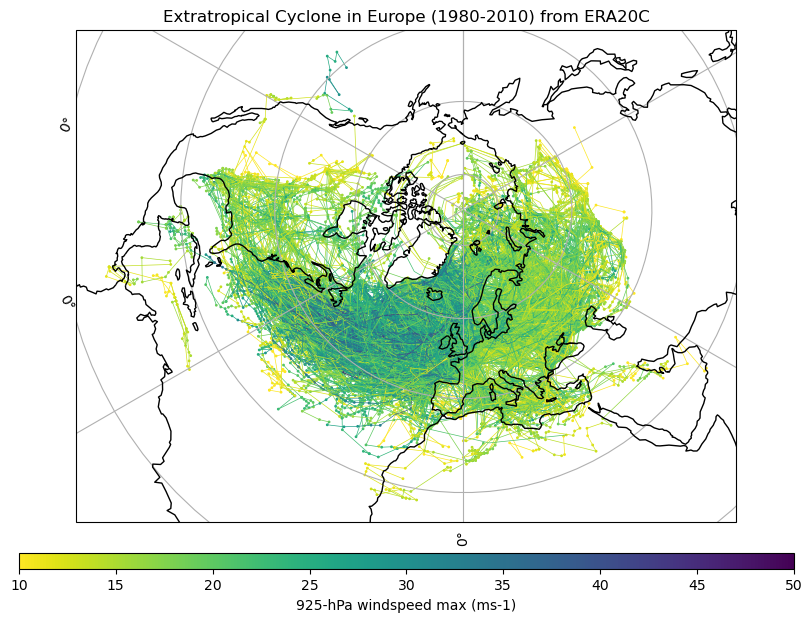

In [34]:
plot_track(trx_20c, 'wind', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

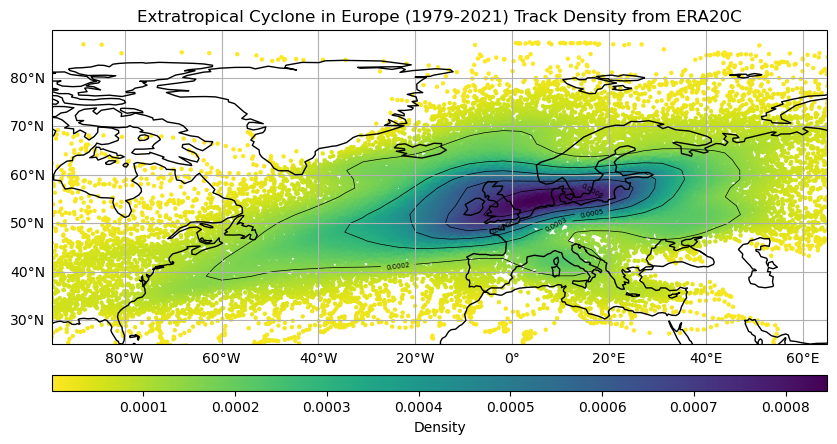

In [33]:
plot_density(trx_20c, 'vor', 'Extratropical Cyclone in Europe (1979-2021) Track Density from ERA20C')

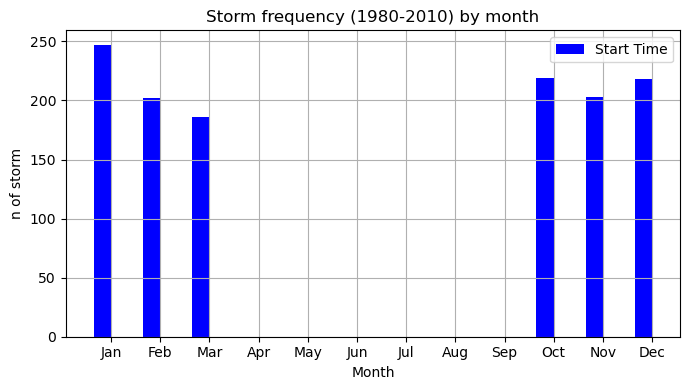

In [46]:
sta_month = trx_20c['start_time'].dropna().unique()
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7., 4.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

ax.bar(sta_positions, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='blue')

ax.set_title('Storm frequency (1980-2010) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

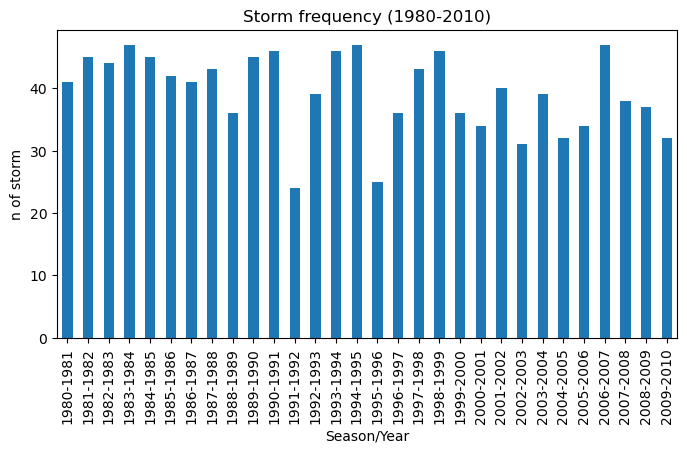

In [44]:
trx_drop = trx_20c.drop_duplicates(subset=['ID'])
season_counts = trx_drop['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1980-2010)')
plt.xlabel('Season/Year')
plt.ylabel('n of storm')
plt.xticks(rotation=90)

#plt.grid(True)
plt.show()

#print("\nCounts per Season:")
#print(season_counts)

## C3S Storm Track ERA5 from CDS

In [6]:
file_track = 'C3S_StormTracks_era5_19792021_0100_v1.dat'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca']

# Read the track data
trx_2021 = read_tracks(file_track, var_names)
trx_2021 = to_datetime(trx_2021)
trx_2021['season'] = trx_2021['median_time'].apply(get_season)
trx_2021

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,...,start_time,median_time,name,lon_ver,lat_ver,var_ver,lon_wind_sca,lat_wind_sca,var_wind_sca,season
0,1979-12-03 00:00:00,306.875519,41.814056,3.916188,308.41530,41.69593,1000.7820,308.5312,41.4520,27.91070,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
1,1979-12-03 03:00:00,310.245422,42.722225,4.112222,310.51570,43.04460,999.0791,311.3438,42.0140,29.84519,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
2,1979-12-03 06:00:00,313.649384,43.700222,4.251033,315.09280,43.77155,994.7399,315.5625,43.4192,29.57939,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
3,1979-12-03 09:00:00,317.070068,44.814579,4.889229,317.38890,46.55165,989.8234,318.6562,44.2623,31.45879,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
4,1979-12-03 12:00:00,320.233734,46.265247,5.254075,320.37530,47.23037,989.8195,325.1250,46.5105,37.14414,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6054,2021-03-24 15:00:00,10.082969,69.874252,5.593984,11.17829,69.98547,963.1310,14.3438,67.5878,38.14269,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6055,2021-03-24 18:00:00,14.000390,70.250389,4.755875,15.12591,70.45399,965.2739,14.0625,67.5878,36.43958,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6056,2021-03-24 21:00:00,19.299009,70.682640,4.126274,18.34388,70.83690,967.6423,15.7500,68.1498,28.82528,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6057,2021-03-25 00:00:00,24.670216,70.705574,4.089319,20.13250,70.71175,971.4703,16.3125,69.2740,26.18828,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021


In [7]:
trx_2021.to_excel("ERA5_ET_track_1979-2021.xlsx")

In [48]:
trx_2021['ID'].nunique()

120

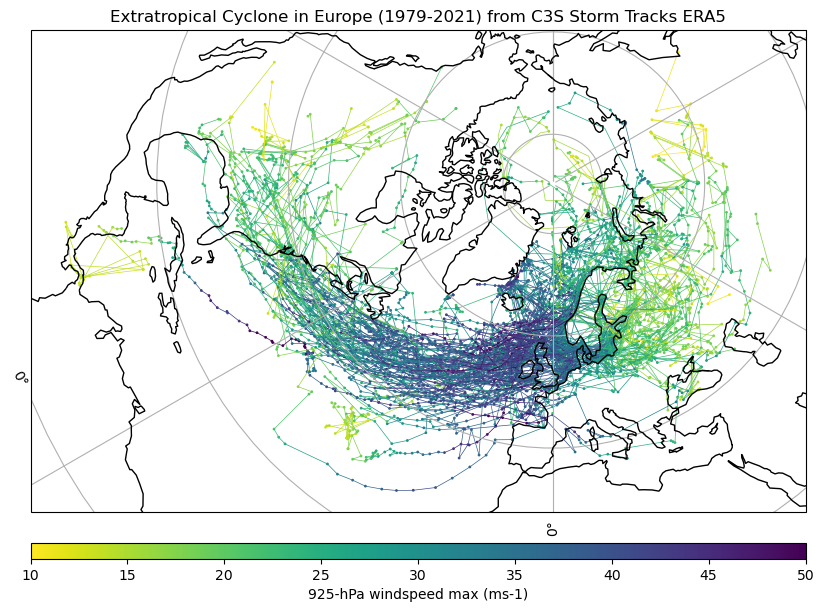

In [36]:
plot_track(trx_2021, 'wind', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')

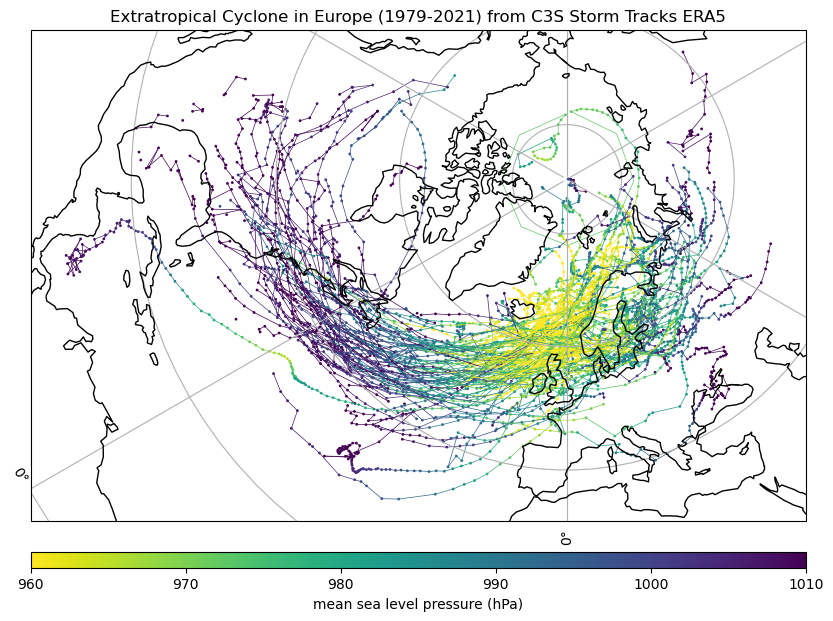

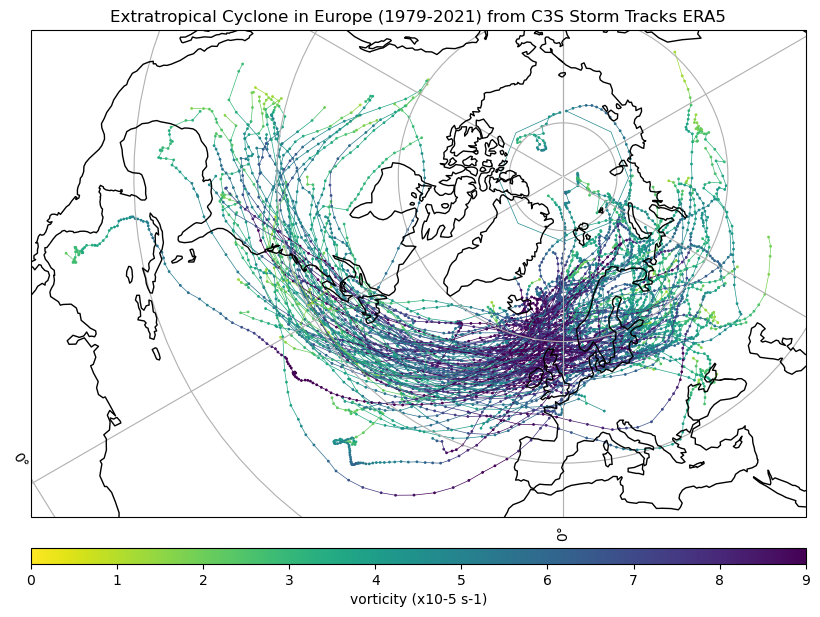

In [37]:
plot_track(trx_2021, 'mslp', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')
plot_track(trx_2021, 'vor', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')

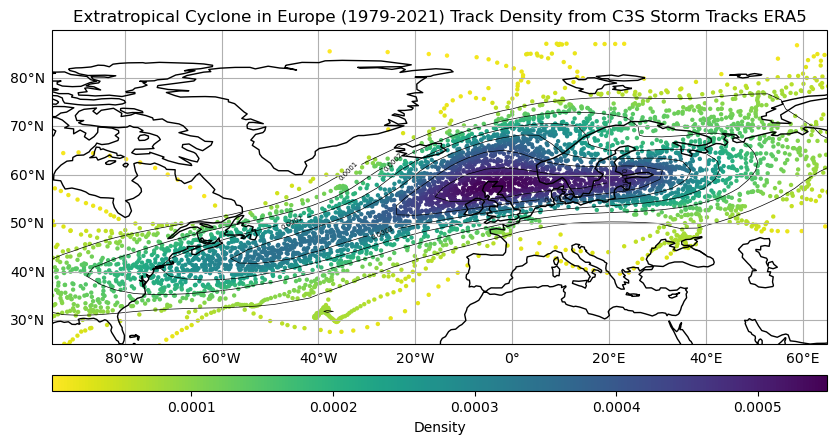

In [38]:
plot_density(trx_2021, 'vor', 'Extratropical Cyclone in Europe (1979-2021) Track Density from C3S Storm Tracks ERA5')

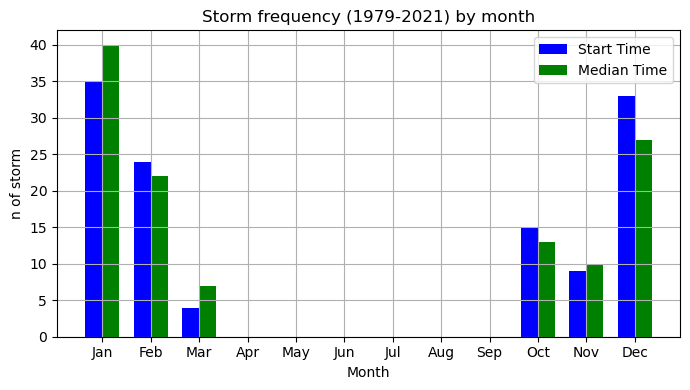

In [47]:
sta_month = trx_2021['start_time'].dropna().unique()
med_month = trx_2021['median_time'].dropna().unique()

sta_months = pd.Series([date.month for date in sta_month])
med_months = pd.Series([date.month for date in med_month])

sta_counts = sta_months.value_counts().sort_index()
med_counts = med_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7., 4.))
months = range(1, 13)
bar_width = 0.35

sta_positions = [x - bar_width/2 for x in months]
med_positions = [x + bar_width/2 for x in months]

ax.bar(sta_positions, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='blue')
ax.bar(med_positions, med_counts.reindex(months, fill_value=0), width=bar_width, label='Median Time', color='green')

ax.set_title('Storm frequency (1979-2021) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

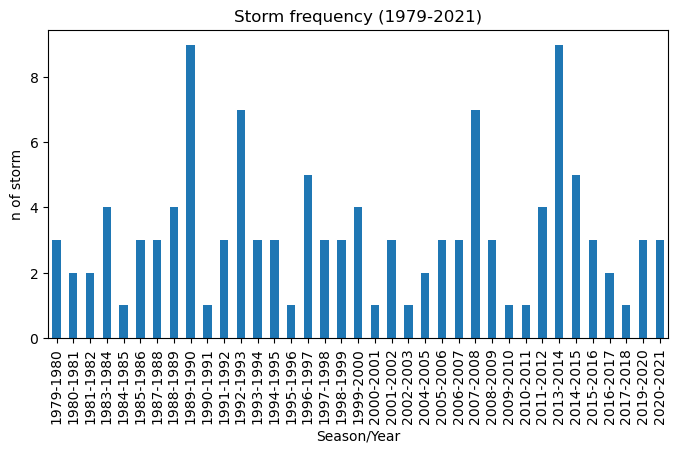

In [43]:
trx_drop = trx_2021.drop_duplicates(subset=['ID'])
season_counts = trx_drop['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1979-2021)')
plt.xlabel('Season/Year')
plt.ylabel('n of storm')
plt.xticks(rotation=90)

#plt.grid(True)
plt.show()

#print("\nCounts per Season:")
#print(season_counts)

## Storm XAver 2013 Footprint

In [2]:
ncdat = xr.open_dataset('C3S_fp_era5_sd_20131205_97_0_Xaver_v1.nc')
ncdat

<xarray.Dataset>
Dimensions:    (Longitude: 3944, Latitude: 2432, z: 1)
Coordinates:
  * Longitude  (Longitude) float64 -25.36 -25.34 -25.32 ... 40.32 40.34 40.36
  * Latitude   (Latitude) float64 70.35 70.33 70.32 70.3 ... 29.87 29.85 29.83
  * z          (z) int32 1
Data variables:
    FX         (z, Latitude, Longitude) float32 ...
Attributes:
    crs:              +proj=longlat +datum=WGS84
    crs_format:       PROJ.4
    Conventions:      CF-1.4
    created_by:       R, packages ncdf4 and raster (version 2.6-7)
    date:             2019-07-02 12:55:37
    title:            C3S operational wind storm
    institution:      Royal Netherlands Meteorological Institute (KNMI)
    contact:          Please contact Copernicus User Support on the Copernicu...
    licence:          Licence to use Copernicus products
    version:          v1
    product_version:  1

In [4]:
fx = ncdat['FX'].sel(z=1).values
lats = ncdat['Latitude']
lons = ncdat['Longitude']

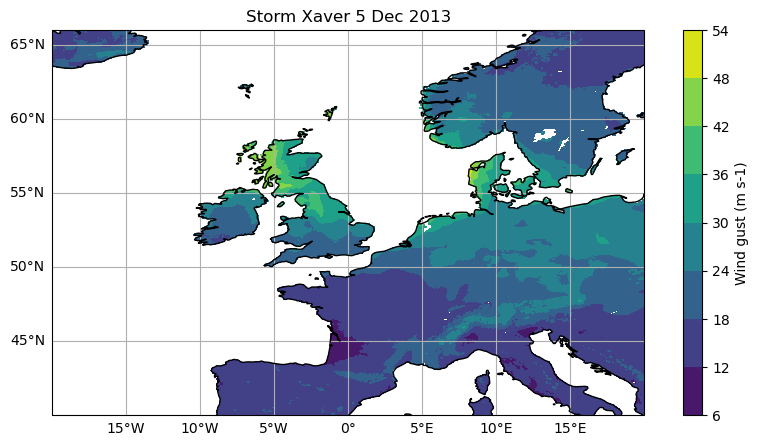

In [7]:
fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
ax.set_extent([-20, 20, 40, 66], crs=ccrs.PlateCarree())


wg = ax.contourf(lons, lats, fx, cmap='viridis', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Storm Xaver 5 Dec 2013')
labelo = 'Wind gust (m s-1)'
cbar = plt.colorbar(wg, ax=ax, orientation='vertical')
cbar.set_label(labelo)

plt.show()

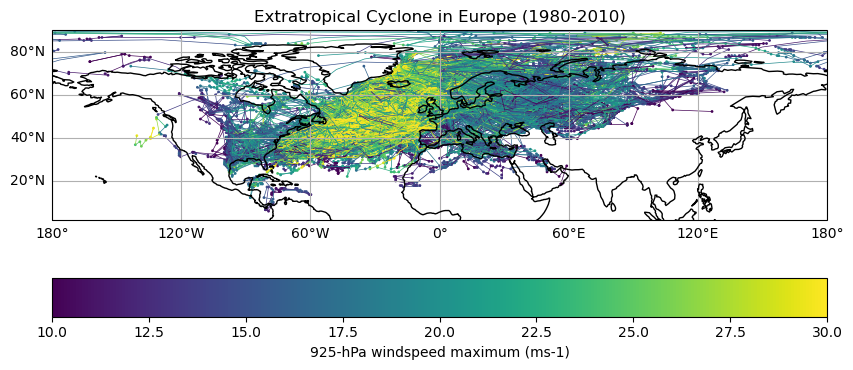

In [10]:
#trx['lon_vor'] = trx['lon_vor'].apply(lambda lon: ((lon + 180) % 360) - 180)
trx['lon_wind'] = trx['lon_wind'].apply(lambda lon: ((lon + 180) % 360) - 180)

fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)

cmap = plt.cm.viridis
norm = plt.Normalize(10, 30)

for name, group in trx.groupby('TRACK_ID'):
    #points = group[['lon_vor', 'lat_vor']].values
    points = group[['lon_wind', 'lat_wind']].values
    lc = ccrs.Geodetic()
    #ax.scatter(group['lon_vor'], group['lat_vor'], color=cmap(norm(group['var_vor'])), s=1, transform=lc)
    ax.scatter(group['lon_wind'], group['lat_wind'], color=cmap(norm(group['var_wind'])), s=1, transform=lc)
    for i in range(len(points)-1):
        line = np.array([points[i], points[i+1]])
        #ax.plot(line[:, 0], line[:, 1], color=cmap(norm((group['var_vor'].iloc[i] + group['var_vor'].iloc[i+1])/2)),
        #        linewidth=0.5, transform=lc)  
        ax.plot(line[:, 0], line[:, 1], color=cmap(norm((group['var_wind'].iloc[i] + group['var_wind'].iloc[i+1])/2)),
                linewidth=0.5, transform=lc)  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Extratropical Cyclone in Europe (1980-2010)')
labelinrv = 'Relative Vorticity (x10-5 s-1)'
labelinws = '925-hPa windspeed maximum (ms-1)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='horizontal', label=labelinws)

plt.show()

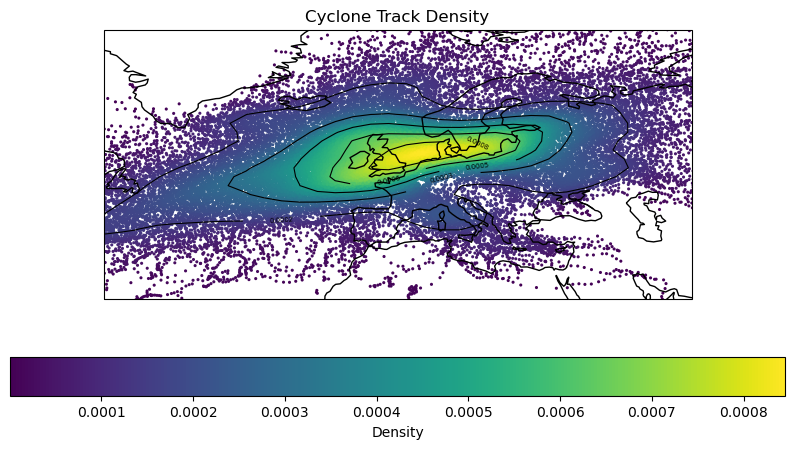

In [19]:
from scipy.stats import gaussian_kde

trx['lon_vor'] = trx['lon_vor'].apply(lambda lon: ((lon + 180) % 360) - 180)
trx['lat_vor'] = trx['lat_vor'].apply(lambda lat: np.clip(lat, -90, 90))

fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)

lon = np.linspace(-180, 180, 100)
lat = np.linspace(-90, 90, 100)
lon_grid, lat_grid = np.meshgrid(lon, lat)
grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

xy = np.vstack([trx['lon_vor'], trx['lat_vor']])
kde = gaussian_kde(xy)
z = kde(grid_coords).reshape(lon_grid.shape)

sc = ax.scatter(trx['lon_vor'], trx['lat_vor'], c=kde(xy), s=5, cmap=plt.cm.viridis, edgecolor='none', transform=ccrs.PlateCarree())
cs = ax.contour(lon_grid, lat_grid, z, levels=6, colors='k', linewidths=0.8, transform=ccrs.PlateCarree())
plt.clabel(cs, inline=1, fontsize=5, fmt='%.4f')

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal')
cbar.set_label('Density')

ax.set_extent([-60, 60, 25, 80], crs=ccrs.PlateCarree())
ax.set_title('Cyclone Track Density')
plt.show()

In [11]:
f = open(file,'r')
print(f)
rd = f.readline()
print(rd)
rd = f.readline()
rd = f.readline().split()
print(rd)
TRACK_NUM = int(rd[1])

for n in range(TRACK_NUM):
    rd = f.readline().split()
    print(rd)
    TRACK_ID = int(rd[1])
    print(TRACK_ID)
    rd = f.readline().split()
    POINT_NUM = int(rd[1])
    TRACK_TIME=[]; TRACK_DATE=[];TRACK_LON=[]; TRACK_LAT=[]; TRACK_VOR=[];TRACK_WND10=[];TRACK_MSLP=[];TRACK_MONTH=[];TRACK_YEAR=[]
    TRACK_WIND=[]; radius_10m=[]; radius_925=[]
    for i in range(POINT_NUM):
       rd = f.readline().split()
       TRACK_TIME.append(int(rd[0].lstrip('0')))
       TRACK_DATE.append(int(rd[0][4:8].lstrip('0')))
       TRACK_MONTH.append(int(rd[0][4:6].lstrip('0')))
       TRACK_YEAR.append(int(rd[0][:4].lstrip('0')))
       TRACK_LON.append(float(rd[1].lstrip('0')))
       TRACK_LAT.append(float(rd[2].lstrip('0')))
       TRACK_VOR.append(float(rd[3].lstrip('0')))
       TRACK_WIND.append(float(rd[-6].lstrip('0')))
       radius_10m.append(float(rd[-2].lstrip('0')))
       radius_925.append(float(rd[-4].lstrip('0')))

<_io.TextIOWrapper name='/badc/deposited2018/robust-storm-track/data/era-20c/ERA20C_tr_trs_VOR850_19802009_pos.addmslp_addspeed_addprecip_addomega_addlandwinds_addavgprecip.new_1000km2dayfiltered_RealProjregion2filtered_maxlandwindsinregion.txt' mode='r' encoding='UTF-8'>
0

['0', '0']


In [35]:
trx.to_excel("ERA20C_ET_track_1980-2010.xlsx")  